# Dictionary

In [1]:
# Dictionary
! pip install google-cloud-bigquery pandas
!pip install ydata-profiling
from google.cloud import bigquery
from google.colab import auth
from matplotlib import pyplot as plt
from ydata_profiling import ProfileReport
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00


# Import Dataset dari Bigquery

In [ ]:
# Download tables
auth.authenticate_user()

project_id = "fsda-sql-467006"
client = bigquery.Client(project=project_id)

print('Authenticated')


Authenticated


In [ ]:
# Masukkan ID yang sudah kita temukan dari screenshot
project_id = "revou-vi-001"
dataset_id = "telkom_oca"

tabel = ['Call', 'Email', 'Sms', 'Users', 'Whatsapp']
data_oca = {}

for nama_tabel in tabel:
  print(f"Sedang mengambil tabel : {nama_tabel}...")

  # Query dinamis: Project ID + Dataset ID + Nama Tabel
  query = f"""
    SELECT *
    FROM `{project_id}.{dataset_id}.{nama_tabel}`
  """

  # Jalankan query
  data_oca[nama_tabel] = client.query(query).to_dataframe()

print("Done! Semua tabel sudah tersimpan di dictionary 'data_oca'")

Sedang mengambil tabel : Call...
Sedang mengambil tabel : Email...
Sedang mengambil tabel : Sms...
Sedang mengambil tabel : Users...
Sedang mengambil tabel : Whatsapp...
Done! Semua tabel sudah tersimpan di dictionary 'data_oca'


In [ ]:
data_oca['Users'].to_csv('users.csv', index=False)
data_oca['Call'].to_csv('call.csv', index=False)
data_oca['Email'].to_csv('email.csv', index=False)
data_oca['Sms'].to_csv('sms.csv', index=False)
data_oca['Whatsapp'].to_csv('whatsapp.csv', index=False)

In [ ]:
df_users = data_oca['Users'].copy()
df_call = data_oca['Call'].copy()
df_email = data_oca['Email'].copy()
df_sms = data_oca['Sms'].copy()
df_whatsapp = data_oca['Whatsapp'].copy()

# Data Preparation

In [ ]:
df_whatsapp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      50000 non-null  object 
 1   user_id             50000 non-null  object 
 2   message_type        50000 non-null  object 
 3   price               50000 non-null  Int64  
 4   last_status         50000 non-null  object 
 5   is_charge           50000 non-null  boolean
 6   created_at          50000 non-null  object 
 7   received_timestamp  42387 non-null  object 
dtypes: Int64(1), boolean(1), object(6)
memory usage: 2.8+ MB


In [ ]:
df_whatsapp.head(2)

,transaction_id,user_id,message_type,price,last_status,is_charge,created_at,received_timestamp
0,6819609cde80fc0012abe3e1,user_1,marketing,400,delivered,True,0025-02-14 09:27:00+00:00,0025-02-14 09:29:00+00:00
1,6838cb9a9eb51800120d7e4b,user_1,marketing,400,delivered,True,0025-01-02 16:21:00+00:00,0025-01-02 16:26:00+00:00


## Cleaning Data

In [ ]:
# kolom whatsapp = last_status menjadi message_status
df_whatsapp.rename(columns={'last_status': 'message_status'}, inplace=True)

In [ ]:
# dataset call kolom total_price menjadi price
df_call.rename(columns={'total_price': 'price'}, inplace=True)

In [ ]:
df_sms['price'] = (
    df_sms['total_price']
    .fillna(df_sms['price'])
    .fillna(0)
    .astype('int64')
)

In [ ]:
# hapus kolom total price pada dataframe sms
df_sms.drop(columns=['total_price'], inplace=True)

In [ ]:
dataset = [df_call, df_email, df_sms, df_whatsapp]
columns = ['created_at', 'received_timestamp']

In [ ]:
for df in dataset:
  for col in columns:
    if col in df.columns:
      # Step 1: Replace '0025-' with '2025-' in string representation to fix the year issue
      df[col] = df[col].astype(str).str.replace('0025-', '2025-', regex=False)
      # Step 2: Convert to datetime, localizing to UTC as the original data implies UTC
      df[col] = pd.to_datetime(df[col], utc=True, errors='coerce', format='mixed')
      # Step 3: Convert the UTC-aware datetime to 'Asia/Jakarta' timezone
      df[col] = df[col].dt.tz_convert('Asia/Jakarta')

In [ ]:
# tambah kolom channel
df_call['channel'] = 'call'
df_email['channel'] = 'email'
df_sms['channel'] = 'sms'
df_whatsapp['channel'] = 'whatsapp'

In [ ]:
df_whatsapp['message_status'] = df_whatsapp['message_status'].str.lower().str.strip()
df_email['message_status'] = df_email['message_status'].str.lower().str.strip()
df_sms['message_status'] = df_sms['message_status'].str.lower().str.strip()
df_call['message_status'] = df_call['message_status'].str.lower().str.strip()

In [ ]:
df_whatsapp.head(2)

,transaction_id,user_id,message_type,price,message_status,is_charge,created_at,received_timestamp,channel
0,6819609cde80fc0012abe3e1,user_1,marketing,400,delivered,True,2025-02-14 16:27:00+07:00,2025-02-14 16:29:00+07:00,whatsapp
1,6838cb9a9eb51800120d7e4b,user_1,marketing,400,delivered,True,2025-01-02 23:21:00+07:00,2025-01-02 23:26:00+07:00,whatsapp


In [ ]:
# menambahkan kolom status mapping dari message status

def map_status(df, channel):
    mapping = {
        'whatsapp': {'read':'success', 'delivered':'success', 'submitted':'pending', 'rejected':'failed'},
        'email': {'opened':'success', 'clicked':'success', 'delivered':'success', 'submitted':'pending', 'processed':'pending', 'failed':'failed'},
        'sms': {'sent':'success', 'failed':'failed'},
        'call': {'answered':'success', 'rna':'pending', 'failed':'failed'}
    }

    if channel not in mapping:
        return df

    df['status_clean'] = df['message_status'].map(mapping[channel])
    return df


In [ ]:
# tambahkan kolom map_status pada setiap dataset
for df in [df_whatsapp, df_email, df_sms, df_call]:
    df = map_status(df, df['channel'].iloc[0])

In [ ]:
# Mapping Status (delivered / read / failed)
status_mapping = {
    "whatsapp": {
        "read": "read",
        "delivered": "delivered",
        "submitted": "delivered",
        "rejected": "failed"
    },
    "email": {
        "opened": "read",
        "clicked": "read",
        "delivered": "delivered",
        "processed": "delivered",
        "submitted": "delivered",
        "failed": "failed"
    },
    "sms": {
        "sent": "delivered",
        "failed": "failed"
    },
    "call": {
        "answered": "read",
        "rna": "failed",
        "failed": "failed"
    }
}


In [ ]:
# Tambah kolom Quality_status_new

# df_whatsapp
df_whatsapp['Quality_status_new'] = df_whatsapp['message_status'].map(status_mapping['whatsapp'])

# df_email
df_email['Quality_status_new'] = df_email['message_status'].map(status_mapping['email'])

# df_sms
df_sms['Quality_status_new'] = df_sms['message_status'].map(status_mapping['sms'])

# df_call
df_call['Quality_status_new'] = df_call['message_status'].map(status_mapping['call'])

## **Data Missing**

In [ ]:
dfs = {'df_users': df_users, 'df_call': df_call, 'df_email': df_email, 'df_sms': df_sms, 'df_whatsapp': df_whatsapp}

In [ ]:
for name, df in dfs.items():
  print(f"Cleaning data for {name}...")
  display(df.isna().sum().to_frame("missing_count"))

Cleaning data for df_users...


,missing_count
user_id,0
user_name,0
field_of_business,0
join_date,0


Cleaning data for df_call...


,missing_count
transaction_id,0
user_id,0
is_charge,0
price,0
created_at,0
message_status,0
channel,0
status_clean,0
Quality_status_new,0


Cleaning data for df_email...


,missing_count
transaction_id,0
user_id,0
is_charge,0
price,0
created_at,0
message_status,0
channel,0
status_clean,0
Quality_status_new,0


Cleaning data for df_sms...


,missing_count
transaction_id,0
user_id,0
is_charge,0
price,0
total_sms,0
created_at,0
message_status,0
channel,0
status_clean,0
Quality_status_new,0


Cleaning data for df_whatsapp...


,missing_count
transaction_id,0
user_id,0
message_type,0
price,0
message_status,0
is_charge,0
created_at,0
received_timestamp,7613
channel,0
status_clean,0


In [ ]:
for name, df in dfs.items():
    missing_pct = (df.isna().mean() * 100).round(2)
    print(f"\n Missing Percentage - {name}")
    display(missing_pct.to_frame("missing_%"))


 Missing Percentage - df_users


,missing_%
user_id,0.0
user_name,0.0
field_of_business,0.0
join_date,0.0



 Missing Percentage - df_call


,missing_%
transaction_id,0.0
user_id,0.0
is_charge,0.0
price,0.0
created_at,0.0
message_status,0.0
channel,0.0
status_clean,0.0
Quality_status_new,0.0



 Missing Percentage - df_email


,missing_%
transaction_id,0.0
user_id,0.0
is_charge,0.0
price,0.0
created_at,0.0
message_status,0.0
channel,0.0
status_clean,0.0
Quality_status_new,0.0



 Missing Percentage - df_sms


,missing_%
transaction_id,0.0
user_id,0.0
is_charge,0.0
price,0.0
total_sms,0.0
created_at,0.0
message_status,0.0
channel,0.0
status_clean,0.0
Quality_status_new,0.0



 Missing Percentage - df_whatsapp


,missing_%
transaction_id,0.00
user_id,0.00
message_type,0.00
price,0.00
message_status,0.00
is_charge,0.00
created_at,0.00
received_timestamp,15.23
channel,0.00
status_clean,0.00


In [ ]:
# menampilkan data yang missing
df_whatsapp[df_whatsapp['received_timestamp'].isna()]

,transaction_id,user_id,message_type,price,message_status,is_charge,created_at,received_timestamp,channel,status_clean,Quality_status_new
8492,683d22f39eb5180012198bb4,user_1,marketing,400,rejected,False,2025-02-15 21:15:00+07:00,NaT,whatsapp,failed,failed
8493,683d4d96f7e73600122a34ed,user_1,utility,200,rejected,False,2025-02-01 22:04:00+07:00,NaT,whatsapp,failed,failed
8494,683e6bdb1e1cd700127b88bd,user_1,utility,200,rejected,False,2025-02-13 19:04:00+07:00,NaT,whatsapp,failed,failed
8495,683eba55848ce100122370cb,user_1,marketing,400,rejected,False,2025-03-19 02:10:00+07:00,NaT,whatsapp,failed,failed
8496,683e91b41e1cd700127d4feb,user_1,marketing,400,rejected,False,2025-03-02 02:52:00+07:00,NaT,whatsapp,failed,failed
...,...,...,...,...,...,...,...,...,...,...,...
49995,683d7a3ef7e73600122baf6d,user_9,service,150,submitted,False,2025-02-09 01:15:00+07:00,NaT,whatsapp,pending,delivered
49996,6843bd80848ce10012340e86,user_9,service,150,submitted,False,2025-02-11 01:56:00+07:00,NaT,whatsapp,pending,delivered
49997,6840319b848ce100122a34cf,user_9,service,150,submitted,False,2025-01-24 15:10:00+07:00,NaT,whatsapp,pending,delivered
49998,683d3c231e1cd700127603ca,user_9,service,150,submitted,False,2025-03-10 22:40:00+07:00,NaT,whatsapp,pending,delivered


### **REKAP DATA MISSING**


* Data Missing pada **received_timestamp** sejumlah **15.23% atau 7613**
* data missing terdiri dari **submmited 88.49% dan rejected 11.51%**
* Kemungkinan **Submitted karena belum ada callback delivery** dan **Rejected karena gagal sebelum dikirim** (Missing karea sistem / lifecycle event issue)


## **Data Duplicate**

In [ ]:
for name, df in dfs.items():
    dup_count = df.duplicated().sum()
    print(f"~ {name}: {dup_count} duplicate rows")

~ df_users: 0 duplicate rows
~ df_call: 0 duplicate rows
~ df_email: 0 duplicate rows
~ df_sms: 0 duplicate rows
~ df_whatsapp: 0 duplicate rows


In [ ]:
pk_map = {
    "df_users": ["user_id"],
    "df_whatsapp": ["transaction_id"],
    "df_email": ["transaction_id"],
    "df_sms": ["transaction_id"],
    "df_call": ["transaction_id"]
}

for name, df in dfs.items():
    pk = pk_map[name]
    dup_pk = df.duplicated(subset=pk).sum()
    print(f"- {name} duplicate PK ({pk}): {dup_pk}")

- df_users duplicate PK (['user_id']): 0
- df_call duplicate PK (['transaction_id']): 0
- df_email duplicate PK (['transaction_id']): 1
- df_sms duplicate PK (['transaction_id']): 0
- df_whatsapp duplicate PK (['transaction_id']): 0


In [ ]:
dup_pk = (
    df_email
    .loc[df_email.duplicated(subset=["transaction_id"], keep=False)]
    .sort_values(by=["transaction_id", "created_at"])
)

dup_pk.head()

,transaction_id,user_id,is_charge,price,created_at,message_status,channel,status_clean,Quality_status_new
11188,6.84E+23,user_3,True,50,2025-02-02 02:52:00+07:00,delivered,email,success,delivered
33611,6.84E+23,user_1,False,0,2025-02-13 01:41:00+07:00,processed,email,pending,delivered


In [ ]:
dup_pk.T

,11188,33611
transaction_id,6.84E+23,6.84E+23
user_id,user_3,user_1
is_charge,True,False
price,50,0
created_at,2025-02-02 02:52:00+07:00,2025-02-13 01:41:00+07:00
message_status,delivered,processed
channel,email,email
status_clean,success,pending
Quality_status_new,delivered,delivered


In [ ]:
df_email['pk_collision'] = (
    df_email
    .duplicated('transaction_id', keep=False)
)


In [ ]:
email_exceptions = df_email[
    df_email['pk_collision']
]

email_clean = df_email[
    ~df_email['pk_collision']
]

assert email_clean['transaction_id'].is_unique


### **REKAP DATA DUPLICATE**

* Ditemukan duplicate pada **df_email** 1 tranx tapi beda users & selisih 11 hari
* Kemungkinan terjadi re-use

## **Union Data**

In [ ]:
union_cols = [
  'transaction_id'
  , 'created_at'
  , 'channel'
  , 'user_id'
  , 'is_charge'
  , 'price'
  , 'message_status'
  , 'status_clean'
  , 'Quality_status_new'
]

In [ ]:
df_union = pd.concat(
    [df_whatsapp, df_email, df_sms, df_call],
    ignore_index=True
)

In [ ]:
df_fact = df_union.merge(
    df_users,
    on='user_id',
    how='left'
)

In [ ]:
df_fact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122749 entries, 0 to 122748
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype                       
---  ------              --------------   -----                       
 0   transaction_id      122749 non-null  object                      
 1   user_id             122749 non-null  object                      
 2   message_type        50000 non-null   object                      
 3   price               122749 non-null  Int64                       
 4   message_status      122749 non-null  object                      
 5   is_charge           122749 non-null  boolean                     
 6   created_at          122749 non-null  datetime64[ns, Asia/Jakarta]
 7   received_timestamp  42387 non-null   datetime64[ns, Asia/Jakarta]
 8   channel             122749 non-null  object                      
 9   status_clean        122749 non-null  object                      
 10  Quality_status_new  122749 non-n

In [ ]:
df_fact.head()

,transaction_id,user_id,message_type,price,message_status,is_charge,created_at,received_timestamp,channel,status_clean,Quality_status_new,pk_collision,total_sms,user_name,field_of_business,join_date
0,6819609cde80fc0012abe3e1,user_1,marketing,400,delivered,True,2025-02-14 16:27:00+07:00,2025-02-14 16:29:00+07:00,whatsapp,success,delivered,NaN,<NA>,CV Land Sejahtera,Real Estate,2022-08-05
1,6838cb9a9eb51800120d7e4b,user_1,marketing,400,delivered,True,2025-01-02 23:21:00+07:00,2025-01-02 23:26:00+07:00,whatsapp,success,delivered,NaN,<NA>,CV Land Sejahtera,Real Estate,2022-08-05
2,683925b91e1cd70012699e41,user_1,marketing,400,delivered,True,2025-03-18 16:20:00+07:00,2025-03-18 16:21:00+07:00,whatsapp,success,delivered,NaN,<NA>,CV Land Sejahtera,Real Estate,2022-08-05
3,683c38a39eb518001215aeb6,user_1,service,150,delivered,True,2025-02-19 23:06:00+07:00,2025-02-19 23:20:00+07:00,whatsapp,success,delivered,NaN,<NA>,CV Land Sejahtera,Real Estate,2022-08-05
4,683d1a2af7e736001227ad9c,user_1,utility,200,delivered,True,2025-02-03 21:02:00+07:00,2025-02-03 21:11:00+07:00,whatsapp,success,delivered,NaN,<NA>,CV Land Sejahtera,Real Estate,2022-08-05


In [ ]:
df_union['status_clean'].value_counts()

,count
status_clean,
success,97638
pending,23527
failed,1584


In [ ]:
df_union['pk_collision'].value_counts()

,count
pk_collision,
False,39998
True,2


In [ ]:
df_union['total_sms'].value_counts()

,count
total_sms,
1,18533
4,861
3,564
2,42


In [ ]:
# hitung KPI total revenue, active user, total transaction, Average delivery rate

df_daily_kpi = (
    df_fact
    .groupby(['created_at', 'channel'])
    .agg(
        total_revenue = ('price', lambda x: (x * df_fact.loc[x.index, 'is_charge']).sum()),
        active_user = ('user_id', 'nunique'),
        total_transaction = ('transaction_id', 'nunique'),
        delivered_rate = ('status_clean', lambda x: (x == 'success').mean() * 100) # Fixed: apply lambda to the Series
    )
    .reset_index()
)


In [ ]:
# Total seluruh revenue dan total revenue setiap channel

total_revenue = df_daily_kpi['total_revenue'].sum()
total_revenue

np.int64(25946420)

In [ ]:
df_daily_kpi.head(10)

,created_at,channel,total_revenue,active_user,total_transaction,delivered_rate
0,2025-01-01 15:00:00+07:00,email,0,1,1,0.0
1,2025-01-01 15:00:00+07:00,whatsapp,150,1,1,100.0
2,2025-01-01 15:01:00+07:00,email,50,1,1,100.0
3,2025-01-01 15:01:00+07:00,sms,1000,2,2,100.0
4,2025-01-01 15:01:00+07:00,whatsapp,400,1,1,100.0
5,2025-01-01 15:02:00+07:00,email,50,2,2,50.0
6,2025-01-01 15:03:00+07:00,whatsapp,400,1,1,100.0
7,2025-01-01 15:04:00+07:00,email,100,2,2,100.0
8,2025-01-01 15:04:00+07:00,whatsapp,400,1,1,100.0
9,2025-01-01 15:05:00+07:00,email,50,1,1,100.0


**Export**

In [ ]:
df_fact.to_csv('df_fact.csv', index=False)
df_daily_kpi.to_csv('df_daily_kpi_new.csv', index=False)

# EDA - Union

In [ ]:
df_fact.head(2)

,transaction_id,user_id,message_type,price,message_status,is_charge,created_at,received_timestamp,channel,status_clean,Quality_status_new,pk_collision,total_sms,user_name,field_of_business,join_date
0,6819609cde80fc0012abe3e1,user_1,marketing,400,delivered,True,2025-02-14 16:27:00+07:00,2025-02-14 16:29:00+07:00,whatsapp,success,delivered,NaN,<NA>,CV Land Sejahtera,Real Estate,2022-08-05
1,6838cb9a9eb51800120d7e4b,user_1,marketing,400,delivered,True,2025-01-02 23:21:00+07:00,2025-01-02 23:26:00+07:00,whatsapp,success,delivered,NaN,<NA>,CV Land Sejahtera,Real Estate,2022-08-05


In [ ]:
# Total Transaction
df_fact.shape[0]
print(f"Total Transaction: {df_fact.shape[0]}")

Total Transaction: 122749


In [ ]:
# Total Revenue
total_revenue_charged = df_fact.loc[df_fact['is_charge'], 'price'].sum()
print(f"Total Revenue: {total_revenue_charged}")

Total Revenue: 25946420


In [ ]:
# Total Revenue per Channel
total_revenue_per_channel = df_fact.groupby('channel')['price'].sum()
print("Total Revenue per Channel:")
print(total_revenue_per_channel)

Total Revenue per Channel:
channel
call         2304220
email        1571350
sms         11813000
whatsapp    11925550
Name: price, dtype: Int64


In [ ]:
# Total user
total_user = df_fact['user_id'].nunique()
print(f"Total User: {total_user}")

Total User: 20


In [ ]:
df_fact['status_clean'].value_counts()

,count
status_clean,
success,97638
pending,23527
failed,1584


In [ ]:
# Average per Transaction
avg_per_transaction = total_revenue_charged / df_fact.shape[0]
print(f"Average per Transaction: {avg_per_transaction:.2f}")

Average per Transaction: 211.38


In [ ]:
# Average Trasaction per Channel
avg_transaction_per_channel = df_fact.groupby('channel')['transaction_id'].nunique()
print("Average Transaction per Channel:")
print(avg_transaction_per_channel)

Average Transaction per Channel:
channel
call        12749
email       39999
sms         20000
whatsapp    50000
Name: transaction_id, dtype: int64


In [ ]:
# Delivery Rate
delivered_rate = (df_fact['status_clean'] == 'success').mean() * 100
print(f"Delivery Rate: {delivered_rate:.2f}%")

Delivery Rate: 79.54%


In [ ]:
# delivery rate per channel
delivery_rate_per_channel = df_fact.groupby('channel')['status_clean'].apply(lambda x: (x == 'success').mean() * 100)
print("Delivery Rate per Channel:")
print(delivery_rate_per_channel)

Delivery Rate per Channel:
channel
call        21.868382
email       81.322500
sms         99.670000
whatsapp    84.774000
Name: status_clean, dtype: float64


In [ ]:
# Effective each channel (delivered / read / failed)
effective_per_channel = df_fact.groupby('channel')['status_clean'].value_counts(normalize=True) * 100
print("Effective each channel (delivered / read / failed):")
print(effective_per_channel)

Effective each channel (delivered / read / failed):
channel   status_clean
call      pending         77.551180
          success         21.868382
          failed           0.580438
email     success         81.322500
          pending         17.257500
          failed           1.420000
sms       success         99.670000
          failed           0.330000
whatsapp  success         84.774000
          pending         13.474000
          failed           1.752000
Name: proportion, dtype: float64


In [ ]:
# Effective each channel (delivered / read / failed) ?
effective_per_channel = df_fact.groupby('channel')['Quality_status_new'].value_counts(normalize=True) * 100
print("Effective each channel (delivered / read / failed):")
print(effective_per_channel)

Effective each channel (delivered / read / failed):
channel   Quality_status_new
call      failed                78.131618
          read                  21.868382
email     delivered             51.600000
          read                  46.980000
          failed                 1.420000
sms       delivered             99.670000
          failed                 0.330000
whatsapp  read                  51.070000
          delivered             47.178000
          failed                 1.752000
Name: proportion, dtype: float64


In [ ]:
# When is message traffic highest (day/hour) ?


In [ ]:
# Are usage trends increasing or decreasing ?

# EDA (Exploratory Data Analysis)

## Quality of Service

### **How effective is each channel (delivered/read/failed) ?**

* Channel SMS lebih efektif dan Call yang tidak efektif karena banyak ditemukan Failed
* Tingginya Failed di channel Call disebabkan oleh RNA (Ring No Answer

In [ ]:
status_mapping = {
    "df_whatsapp": {
        "read": "success",
        "delivered": "success",
        "submitted": "pending",
        "rejected": "failed"
    },
    "df_email": {
        "opened": "success",
        "clicked": "success",
        "delivered": "success",
        "processed": "pending",
        "submitted": "pending",
        "failed": "failed"
    },
    "df_sms": {
        "sent": "success",
        "failed": "failed"
    },
    "df_call": {
        "answered": "success",
        "rna": "failed",      # ring no answer = ga terjawab
        "failed": "failed"
    }
}


In [ ]:
# Tambah kolom Quality_status

# df_whatsapp
df_whatsapp['quality_status'] = df_whatsapp['last_status'].map(status_mapping['df_whatsapp'])

# df_email
df_email['quality_status'] = df_email['message_status'].map(status_mapping['df_email'])

# df_sms
df_sms['quality_status'] = df_sms['message_status'].map(status_mapping['df_sms'])

# df_call
df_call['quality_status'] = df_call['message_status'].map(status_mapping['df_call'])

In [ ]:
df_whatsapp['quality_status'].value_counts(dropna=False)

,count
quality_status,
success,42387
pending,6737
failed,876


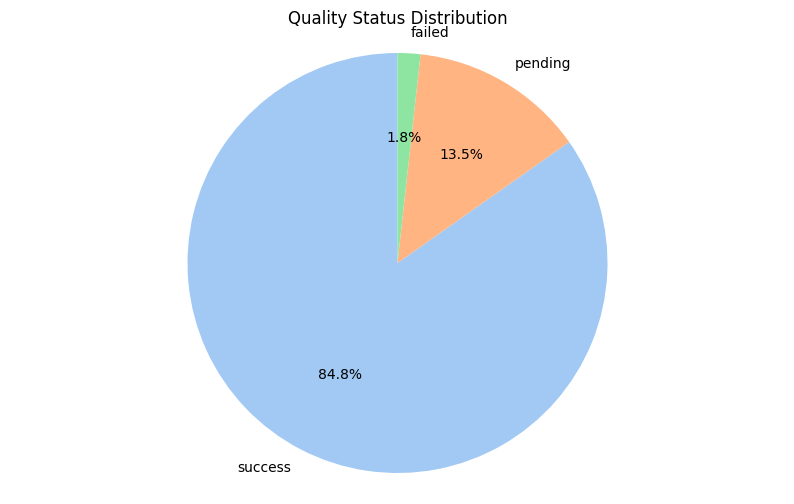

In [ ]:
# visualisasi qualitu status dengan diagram pie

plt.figure(figsize=(10, 6))

labels = df_whatsapp['quality_status'].value_counts().index
sizes = df_whatsapp['quality_status'].value_counts().values
colors = sns.color_palette('pastel')[0:4]

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Quality Status Distribution')
plt.axis('equal')
plt.show()


In [ ]:
status_cols = {
    "df_whatsapp": "last_status",
    "df_email": "message_status",
    "df_sms": "message_status",
    "df_call": "message_status"
}

summary = []

# Iterate only over the keys that are present in status_cols
for channel_name_key in status_cols.keys():
    df = dfs[channel_name_key]
    status_col = status_cols[channel_name_key]
    mapping = status_mapping[channel_name_key]

    temp = df.copy()
    temp['outcome'] = temp[status_col].map(mapping).fillna("other")

    channel_summary = (
        temp['outcome']
        .value_counts()
        .to_frame("count")
        .assign(channel=channel_name_key)
        .reset_index()
        .rename(columns={"index": "outcome"})
    )

    summary.append(channel_summary)

effectiveness_df = pd.concat(summary, ignore_index=True)
effectiveness_df

,outcome,count,channel
0,success,42387,df_whatsapp
1,pending,6737,df_whatsapp
2,failed,876,df_whatsapp
3,success,32529,df_email
4,pending,6903,df_email
5,failed,568,df_email
6,success,19934,df_sms
7,failed,66,df_sms
8,failed,9961,df_call
9,success,2788,df_call


In [ ]:
effectiveness_pct = (
    effectiveness_df
    .pivot(index='channel', columns='outcome', values='count')
    .fillna(0)
)

effectiveness_pct = (
    effectiveness_pct
    .div(effectiveness_pct.sum(axis=1), axis=0) * 100
).round(2)

effectiveness_pct


outcome,failed,pending,success
channel,,,
df_call,78.13,0.00,21.87
df_email,1.42,17.26,81.32
df_sms,0.33,0.00,99.67
df_whatsapp,1.75,13.47,84.77


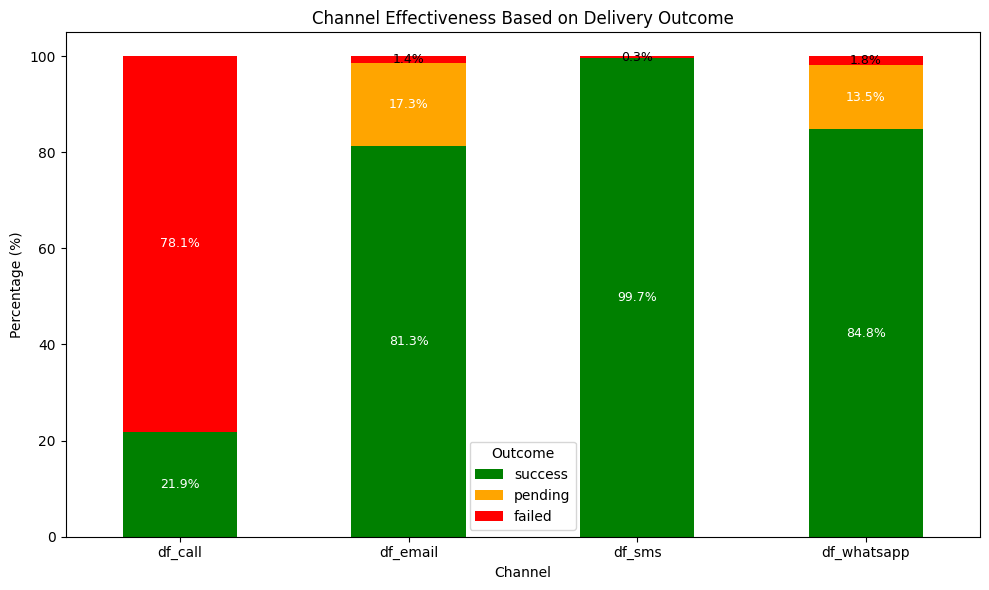

In [ ]:
ax = effectiveness_pct[['success', 'pending', 'failed']].plot(
    kind='bar',
    stacked=True,
    color=['green', 'orange', 'red'],
    figsize=(10, 6)
)

plt.title("Channel Effectiveness Based on Delivery Outcome")
plt.ylabel("Percentage (%)")
plt.xlabel("Channel")
plt.xticks(rotation=0)
plt.legend(title="Outcome")

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # tampilkan hanya jika ada nilainya
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white' if height > 8 else 'black'
            )

plt.tight_layout()
plt.show()

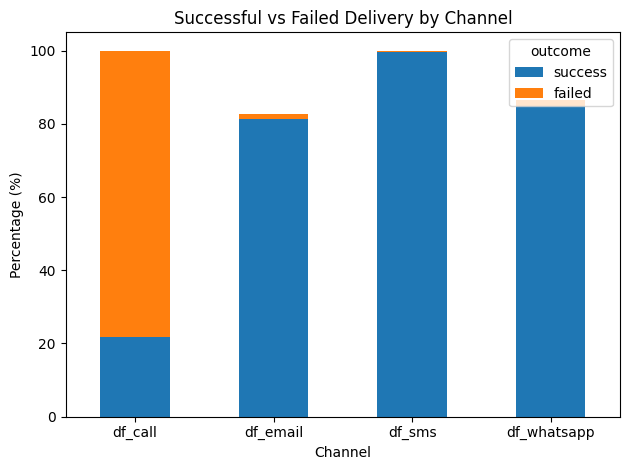

In [ ]:
(effectiveness_pct[['success', 'failed']]
 .plot(kind='bar', stacked=True))

plt.title("Successful vs Failed Delivery by Channel")
plt.ylabel("Percentage (%)")
plt.xlabel("Channel")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
df_call['message_status'].value_counts()

,count
message_status,
rna,9887
answered,2788
failed,74


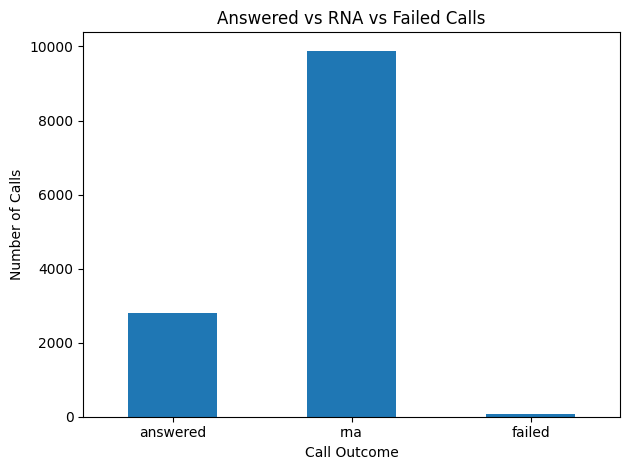

In [ ]:
df_call['message_status'].value_counts().loc[['answered', 'rna', 'failed']].plot(
    kind='bar'
)

plt.title("Answered vs RNA vs Failed Calls")
plt.xlabel("Call Outcome")
plt.ylabel("Number of Calls")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# SImpan File
effectiveness_pct.to_csv('effectiveness_pct.csv')

#### **Statistik Latency (Whatsapp)**

In [ ]:
# Latency Whatsapp - karena ada timestamp

wa_latency = df_whatsapp[
    df_whatsapp['received_timestamp'].notna()
].copy()

wa_latency['delivery_time_seconds'] = (
    wa_latency['received_timestamp'] -
    wa_latency['created_at']
).dt.total_seconds()

wa_latency['delivery_time_seconds'].describe()

,delivery_time_seconds
count,42387.000000
mean,349.414679
std,281.419621
min,60.000000
25%,60.000000
50%,300.000000
75%,600.000000
max,900.000000


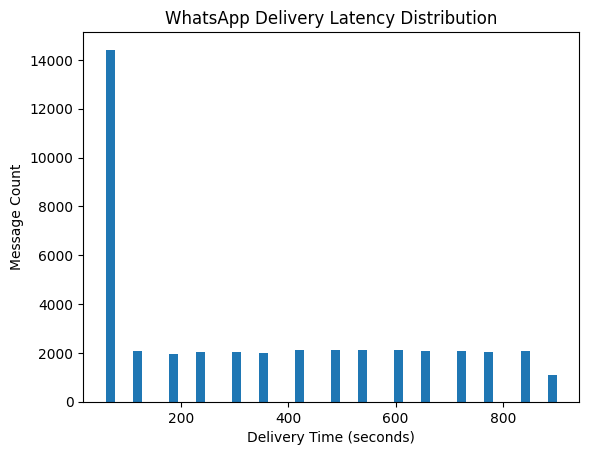

In [ ]:
plt.hist(wa_latency['delivery_time_seconds'], bins=50)
plt.title('WhatsApp Delivery Latency Distribution')
plt.xlabel('Delivery Time (seconds)')
plt.ylabel('Message Count')
plt.show()

In [ ]:
# SLA Breach Detection

sla_threshold = 10

wa_latency['sla_breach'] = (
    wa_latency['delivery_time_seconds'] > sla_threshold
)

wa_latency['sla_breach'].value_counts(normalize=True)

,proportion
sla_breach,
True,1.0


In [ ]:
# Quality Distribution Score per Channel

def quality_summary(df, channel):
    return (
        df['quality_status']
        .value_counts()
        .rename_axis('quality')
        .reset_index(name='count')
        .assign(channel=channel)
    )

quality_df = pd.concat([
    quality_summary(df_whatsapp, 'WA'),
    quality_summary(df_email, 'Email'),
    quality_summary(df_sms, 'SMS'),
    quality_summary(df_call, 'Call')
])



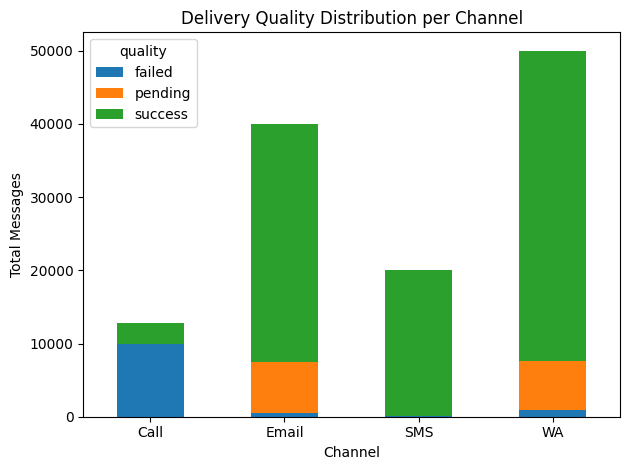

In [ ]:

pivot_quality = (
    quality_df
    .pivot(index='channel', columns='quality', values='count')
    .fillna(0)
)

pivot_quality.plot(kind='bar', stacked=True)
plt.title('Delivery Quality Distribution per Channel')
plt.ylabel('Total Messages')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
quality_score = (
    quality_df
    .assign(weight=lambda x: x['quality'].map({
        'success': 1,
        'pending': 0.5,
        'failed': 0
    }))
    .assign(score=lambda x: x['count'] * x['weight'])
    .groupby('channel')
    .apply(lambda x: x['score'].sum() / x['count'].sum())
    .reset_index(name='quality_score')
)

quality_score

/tmp/ipython-input-4231256362.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['score'].sum() / x['count'].sum())


,channel,quality_score
0,Call,0.218684
1,Email,0.899513
2,SMS,0.996700
3,WA,0.915110


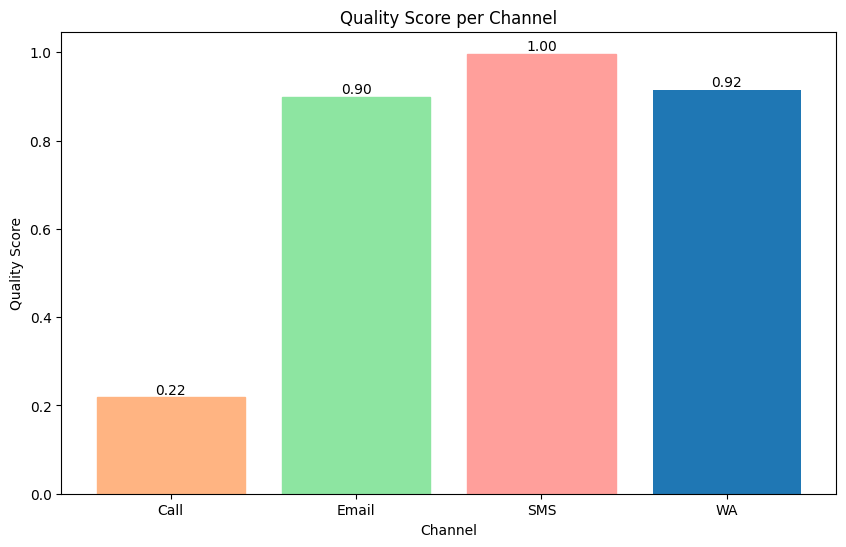

In [ ]:
# visualisasi quality score

plt.figure(figsize=(10, 6))

bars = plt
bars = plt.bar(quality_score['channel'], quality_score['quality_score'])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

colors = sns.color_palette('pastel')[1:4]
for bar, color in zip(bars, colors):
    bar.set_color(color)
plt.xlabel('Channel')
plt.ylabel('Quality Score')
plt.title('Quality Score per Channel')
plt.show()

In [ ]:
# Simpan File

quality_score.to_csv('quality_score.csv')
quality_df.to_csv('quality_score.csv')

print (f"kualitas data \n{quality_df}\n")
print (f"kualitas data \n{quality_score}")



kualitas data 
   quality  count channel
0  success  42387      WA
1  pending   6737      WA
2   failed    876      WA
0  success  32529   Email
1  pending   6903   Email
2   failed    568   Email
0  success  19934     SMS
1   failed     66     SMS
0   failed   9961    Call
1  success   2788    Call

kualitas data 
  channel  quality_score
0    Call       0.218684
1   Email       0.899513
2     SMS       0.996700
3      WA       0.915110


## Customer Behavior

### **When is message traffic highest (day/hour) ?**

* Traffic tertinggi pada jam 18 sebesar 9.865
* Traffic tertinggi pada hari Friday 18.084

In [ ]:
traffic_df = pd.concat([
    df_whatsapp[['created_at']].assign(channel='WA'),
    df_email[['created_at']].assign(channel='Email'),
    df_sms[['created_at']].assign(channel='SMS'),
    df_call[['created_at']].assign(channel='Call')
], ignore_index=True)

traffic_df['hour'] = traffic_df['created_at'].dt.hour
traffic_df['day_name'] = traffic_df['created_at'].dt.day_name()
traffic_df['day_num'] = traffic_df['created_at'].dt.weekday

In [ ]:
# Traffic by Hour
traffic_by_hour = traffic_df.groupby('hour').size().sort_values(ascending=False)
traffic_by_hour

,0
hour,
18,9865
19,9843
16,9791
21,9767
17,9761
22,9749
23,9704
15,9697
20,9650


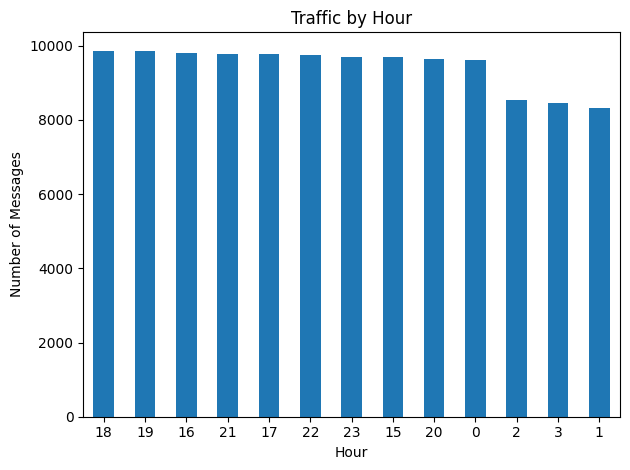

In [ ]:
traffic_by_hour.plot(kind='bar')
plt.title('Traffic by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Traffic by Days
traffic_by_day = (
    traffic_df
    .groupby(['day_num','day_name'])
    .size()
    .reset_index(name='count')
    .sort_values(by='day_num', ascending=True))
traffic_by_day

,day_num,day_name,count
0,0,Monday,17148
1,1,Tuesday,16712
2,2,Wednesday,17670
3,3,Thursday,17946
4,4,Friday,18084
5,5,Saturday,17510
6,6,Sunday,17679


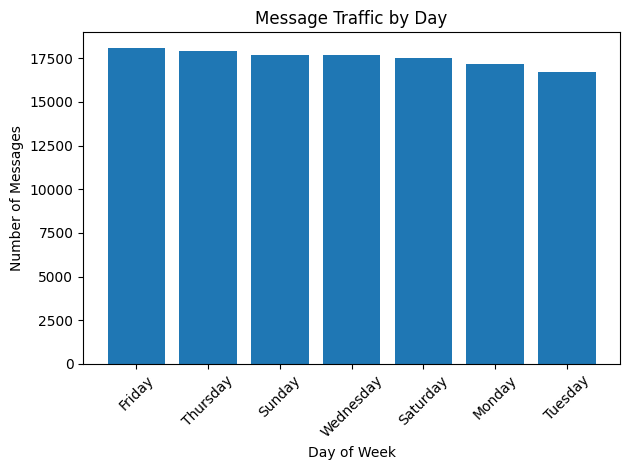

In [ ]:
traffic_sorted = traffic_by_day.sort_values(by='count', ascending=False)

plt.figure()
plt.bar(traffic_sorted['day_name'], traffic_sorted['count'])

plt.title("Message Traffic by Day")
plt.xlabel("Day of Week")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45)
#sort berdasarkan paling besar
plt.tight_layout()
plt.show()


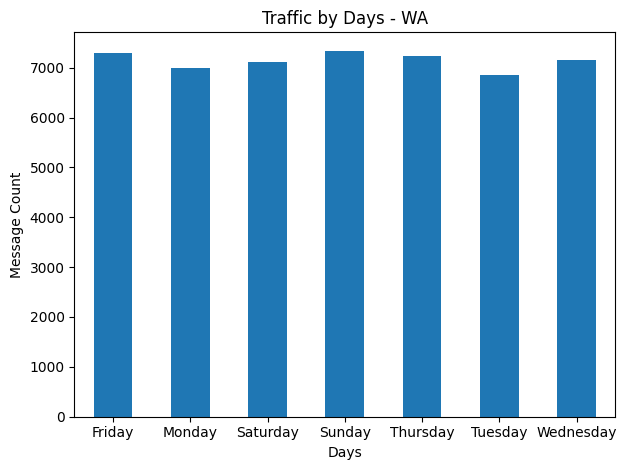

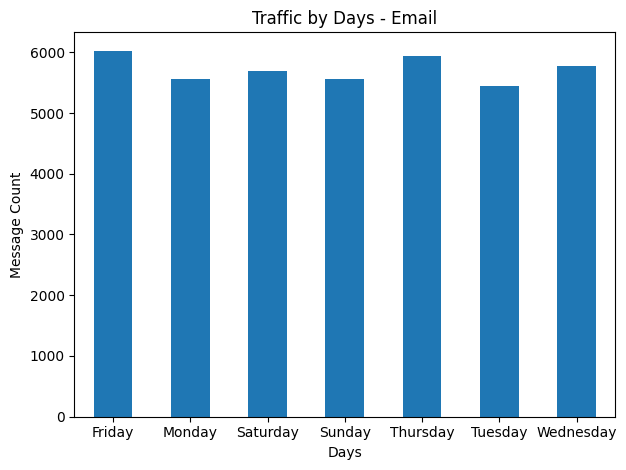

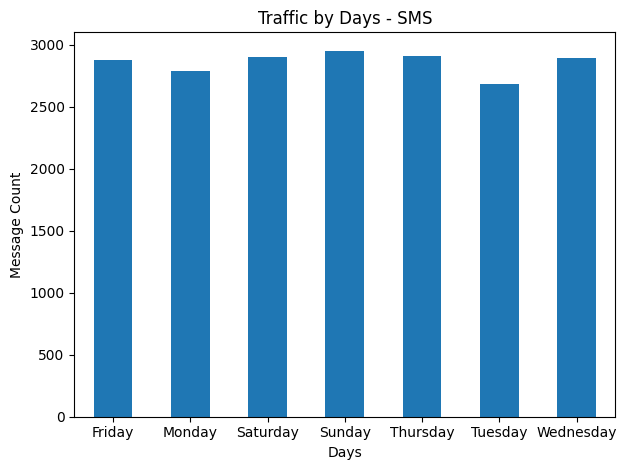

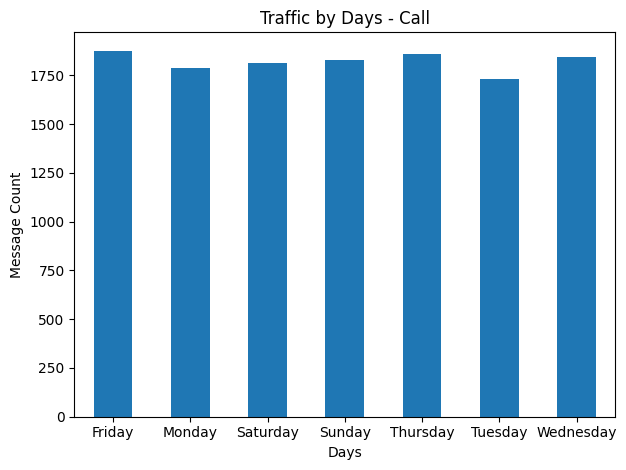

In [ ]:
for channel in traffic_df['channel'].unique():
    temp = traffic_df[traffic_df['channel'] == channel]
    temp.groupby('day_name').size().plot(kind='bar')

    plt.title(f"Traffic by Days - {channel}")
    plt.xlabel("Days")
    plt.ylabel("Message Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [ ]:
# SImpan File
traffic_df.to_csv('traffic_df.csv')
traffic_by_day.to_csv('traffic_by_day.csv')
traffic_by_hour.to_csv('traffic_by_hour.csv')


### **Are usage trends increasing or decreasing ?**

In [ ]:
# Create AT di semua channel

create_data = {
    "df_whatsapp": df_whatsapp.assign(created_at=lambda x: x['created_at'].dt.date),
    "df_email": df_email.assign(created_at=lambda x: x['created_at'].dt.date),
    "df_sms": df_sms.assign(created_at=lambda x: x['created_at'].dt.date),
    "df_call": df_call.assign(created_at=lambda x: x['created_at'].dt.date)
}



for name, df_with_date_col in create_data.items():
    print(f"\n Create AT Distribution - {name}")
    display(
        df_with_date_col['created_at']
        .value_counts()
        .to_frame("count")
        .sort_values(by='created_at', ascending=False)
    )


 Create AT Distribution - df_whatsapp


,count
created_at,
2025-03-31,178
2025-03-30,567
2025-03-29,534
2025-03-28,567
2025-03-27,508
...,...
2025-01-05,582
2025-01-04,546
2025-01-03,562



 Create AT Distribution - df_email


,count
created_at,
2025-04-01,76
2025-03-31,252
2025-03-30,270
2025-03-29,242
2025-03-28,280
...,...
2025-01-05,591
2025-01-04,672
2025-01-03,679



 Create AT Distribution - df_sms


,count
created_at,
2025-03-31,64
2025-03-30,201
2025-03-29,200
2025-03-28,210
2025-03-27,212
...,...
2025-01-05,222
2025-01-04,226
2025-01-03,222



 Create AT Distribution - df_call


,count
created_at,
2025-04-01,21
2025-03-31,129
2025-03-30,112
2025-03-29,116
2025-03-28,128
...,...
2025-01-05,177
2025-01-04,168
2025-01-03,169


In [ ]:
# Data usage seluruh channel

usage_df = pd.concat([
    df_whatsapp[['user_id', 'created_at']].assign(channel='WA'),
    df_email[['user_id', 'created_at']].assign(channel='Email'),
    df_sms[['user_id', 'created_at']].assign(channel='SMS'),
    df_call[['user_id', 'created_at']].assign(channel='Call')
], ignore_index=True)

usage_df['date'] = usage_df['created_at'].dt.date
usage_df['month'] = usage_df['created_at'].dt.to_period('M').astype(str)

daily_usage = usage_df.groupby('date').size()

daily_usage.sort_index(ascending=True)

daily_usage

/tmp/ipython-input-2630704529.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usage_df['month'] = usage_df['created_at'].dt.to_period('M').astype(str)


,0
date,
2025-01-01,1178
2025-01-02,1567
2025-01-03,1632
2025-01-04,1612
2025-01-05,1572
...,...
2025-03-28,1185
2025-03-29,1092
2025-03-30,1150


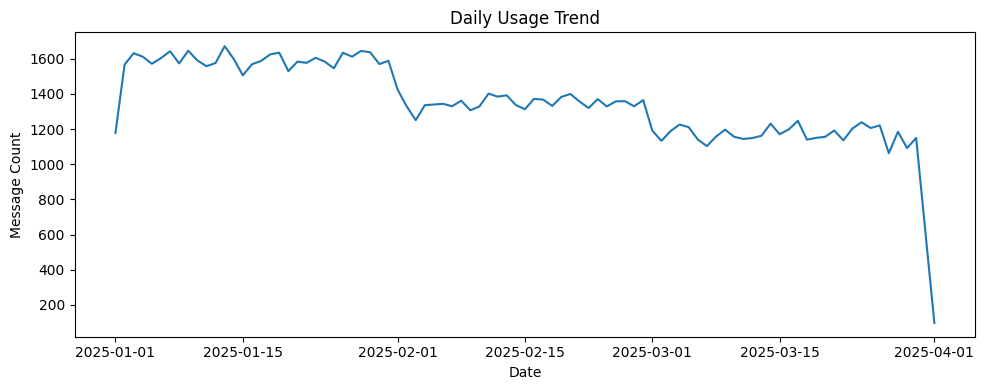

In [ ]:
plt.figure(figsize=(10, 4))
daily_usage.plot()

plt.title("Daily Usage Trend")
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.tight_layout()
plt.show()

In [ ]:
# Daily trend per channel

channel_daily = (
    usage_df
    .groupby(['date', 'channel'])
    .size()
    .unstack(fill_value=0)
)

channel_daily.sort_index(ascending=True)


channel,Call,Email,SMS,WA
date,,,,
2025-01-01,136,455,161,426
2025-01-02,159,657,227,524
2025-01-03,169,679,222,562
2025-01-04,168,672,226,546
2025-01-05,177,591,222,582
...,...,...,...,...
2025-03-28,128,280,210,567
2025-03-29,116,242,200,534
2025-03-30,112,270,201,567


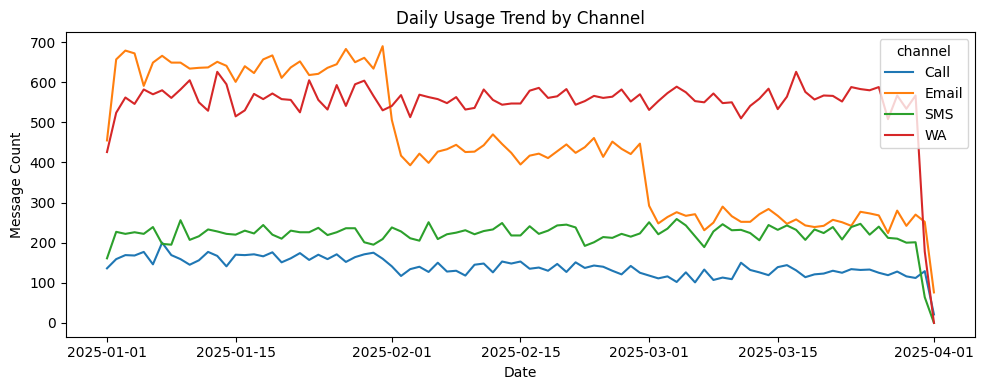

In [ ]:
channel_daily.plot(figsize=(10,4))

plt.title("Daily Usage Trend by Channel")
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

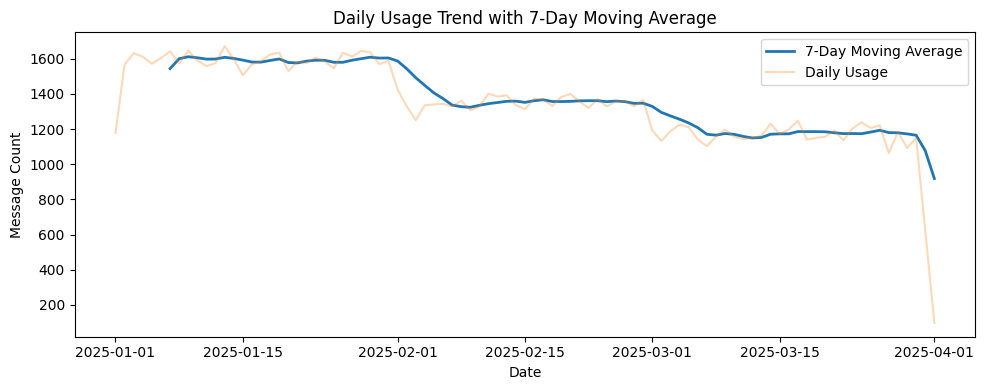

In [ ]:
daily_usage_ma = daily_usage.rolling(window=7).mean()

plt.figure(figsize=(10, 4))
plt.plot(daily_usage_ma, linewidth=2, label='7-Day Moving Average')
plt.plot(daily_usage, alpha=0.3, label='Daily Usage')

plt.title("Daily Usage Trend with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.legend()
plt.tight_layout()
plt.show()

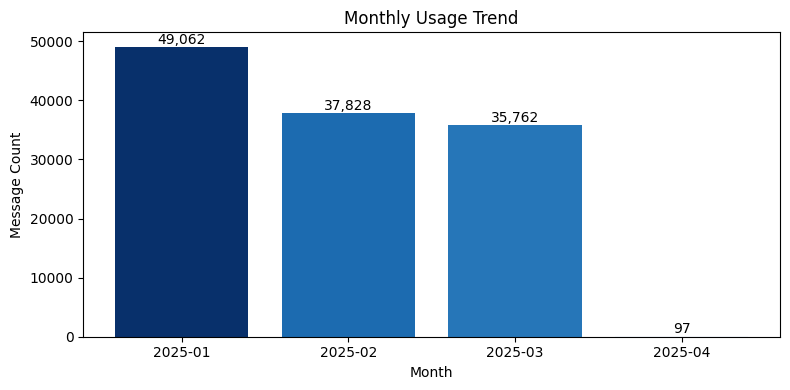

In [ ]:
# Trend Bulanan (Jawaban Paling “Executive”)
monthly_usage = usage_df.groupby('month').size()

labels = list(monthly_usage.keys())
values = monthly_usage.tolist()
colors = plt.cm.Blues(monthly_usage.values / monthly_usage.values.max())

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color = colors)

plt.title("Monthly Usage Trend")
plt.xlabel("Month")
plt.ylabel("Message Count")
plt.tight_layout()
plt.xticks(rotation=0)



for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,}',
        ha='center',
        va='bottom'
    )


plt.show()

In [ ]:
monthly_usage

,0
month,
2025-01,49062
2025-02,37828
2025-03,35762
2025-04,97


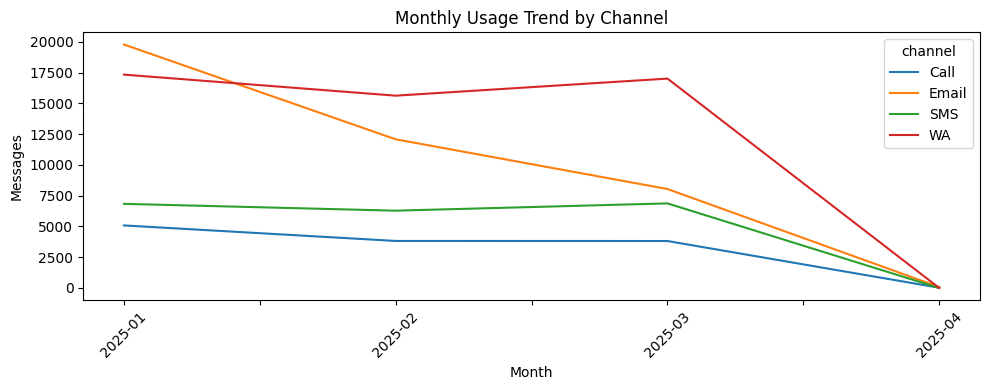

In [ ]:
channel_monthly = (
    usage_df
    .groupby(['month', 'channel'])
    .size()
    .unstack(fill_value=0)
)

channel_monthly.plot(figsize=(10,4))

plt.title("Monthly Usage Trend by Channel")
plt.xlabel("Month")
plt.ylabel("Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


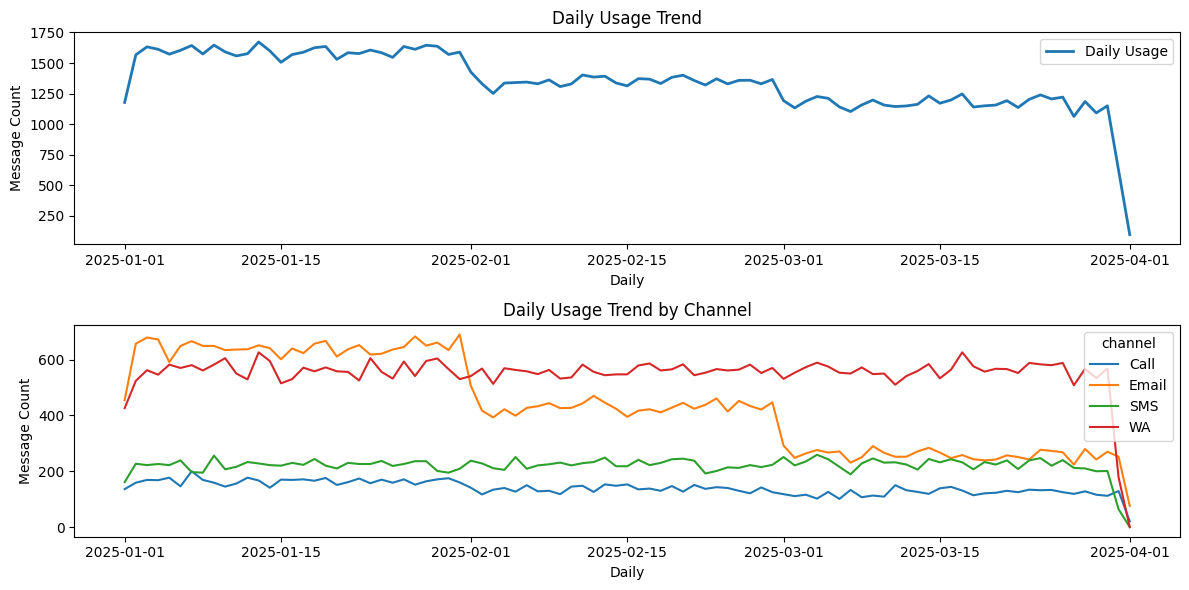

In [ ]:
# Join Trend Daily

plt.figure(figsize=(12, 6))

# Plot Monthly Usage Trend
plt.subplot(2, 1, 1)
plt.plot(daily_usage, linewidth=2, label='Daily Usage')
plt.title("Daily Usage Trend")
plt.xlabel("Daily")
plt.ylabel("Message Count")
plt.legend()

# Plot Monthly Usage Trend by Channel
plt.subplot(2, 1, 2)
channel_daily.plot(ax=plt.gca())
plt.title("Daily Usage Trend by Channel")
plt.xlabel("Daily")
plt.ylabel("Message Count")
plt.tight_layout()

plt.show()

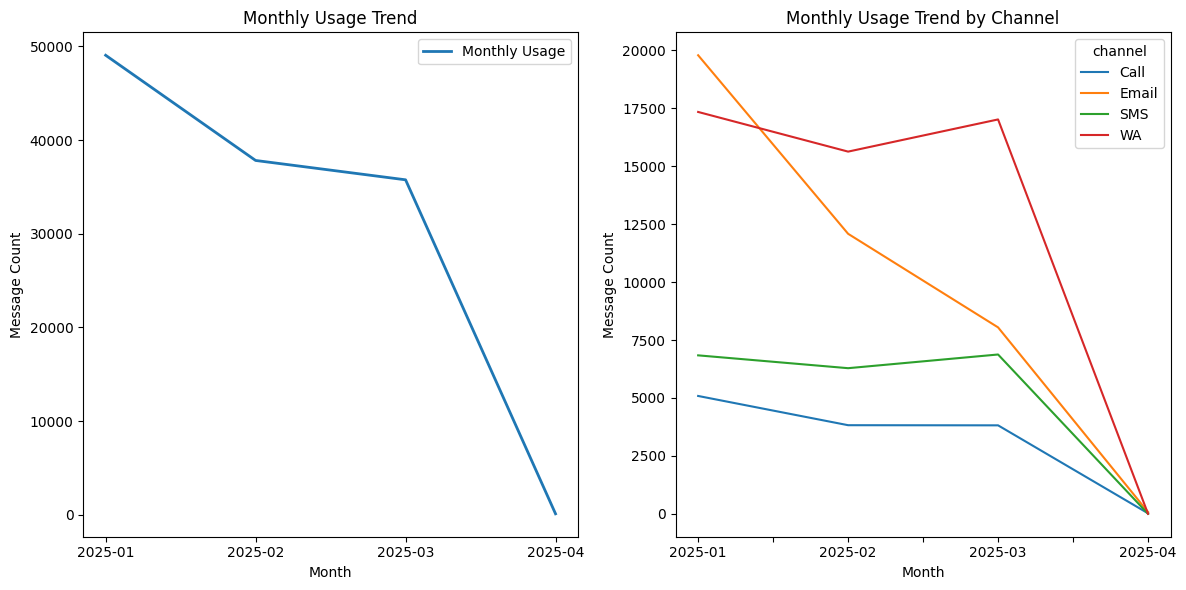

In [ ]:
# Join Trend Monthly

plt.figure(figsize=(12, 6))

# Plot Monthly Usage Trend
plt.subplot(1, 2, 1)
plt.plot(monthly_usage, linewidth=2, label='Monthly Usage')
plt.title("Monthly Usage Trend")
plt.xlabel("Month")
plt.ylabel("Message Count")
plt.legend()

# Plot Monthly Usage Trend by Channel
plt.subplot(1, 2, 2)
channel_monthly.plot(ax=plt.gca())
plt.title("Monthly Usage Trend by Channel")
plt.xlabel("Month")
plt.ylabel("Message Count")
plt.tight_layout()

plt.show()

In [ ]:
# Growth rate sederhana (month-over-month)
monthly_growth = monthly_usage.pct_change() * 100
monthly_growth.round(2)

,0
month,
2025-01,NaN
2025-02,-22.90
2025-03,-5.46
2025-04,-99.73


In [ ]:
# SImpan File
daily_usage.to_csv('daily_usage.csv')
monthly_usage.to_csv('monthly_usage.csv')
channel_daily.to_csv('channel_daily.csv')
channel_monthly.to_csv('channel_monthly.csv')

### **who are the top users (by volume & active days) ?**

* Seluruh top users menunjukkan konsistensi maksimal dengan aktif setiap hari (91)
* Berdasarkan Volume User_3 (CV Wisata Indo) merupakan pengguna tertinggi diikuti user_2 (PT Dana Nusantara) dan user_1 (CV Land Sejahtera)

In [ ]:
user_activity = pd.concat([
    df_whatsapp[['user_id','created_at']],
    df_email[['user_id','created_at']],
    df_sms[['user_id','created_at']],
    df_call[['user_id','created_at']]
], ignore_index=True)

user_activity['date'] = user_activity['created_at'].dt.date
user_activity['day_name'] = user_activity['created_at'].dt.day_name()

In [ ]:
# Active days per USER / User Active berapa hari

user_metrics = (
    user_activity
    .groupby('user_id')
    .agg(
        total_volume=('created_at', 'count'),
        active_days=('date', 'nunique')
    )
    .reset_index()
)

In [ ]:
# user tertinggi berdasarkan total volume & active days

top_users = (
    user_metrics
    .merge(df_users, on='user_id', how='left')
    .sort_values(
    by=['total_volume','active_days'] , ascending=False
))

top_users.to_csv('top_users.csv')

top_users


,user_id,total_volume,active_days,user_name,field_of_business,join_date
13,user_3,24635,91,CV Wisata Indo,Travel,2024-02-22
11,user_2,24518,91,PT Dana Nusantara,Finance,2024-03-27
0,user_1,24496,91,CV Land Sejahtera,Real Estate,2022-08-05
14,user_4,6230,91,PT Konektivitas Indo,Telecommunications,2022-08-11
15,user_5,6198,91,PT Karya Sejahtera,Education,2024-12-19
17,user_7,6132,91,PT Retail Sejahtera,Retail,2024-10-14
18,user_8,6117,91,PT Belajar Nusantara,Education,2024-02-06
16,user_6,6010,91,PT Logistik Mandiri,Logistics,2024-05-01
7,user_16,1593,91,PT Estate Sejahtera,Real Estate,2024-01-03
9,user_18,1573,91,CV Jalan Mandiri,Travel,2022-08-27


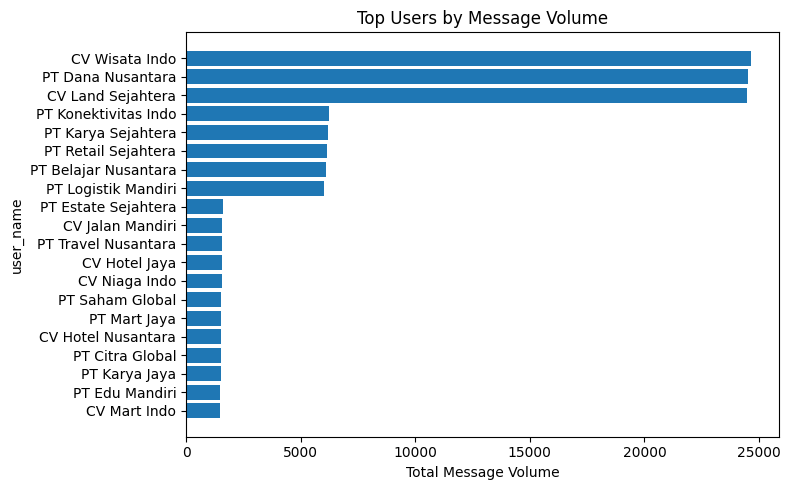

In [ ]:
# visualisasi top users

plt.figure(figsize=(8,5))
plt.barh(top_users['user_name'], top_users['total_volume'])
plt.gca().invert_yaxis()

plt.title("Top Users by Message Volume")
plt.xlabel("Total Message Volume")
plt.ylabel("user_name")
plt.tight_layout()
plt.show()

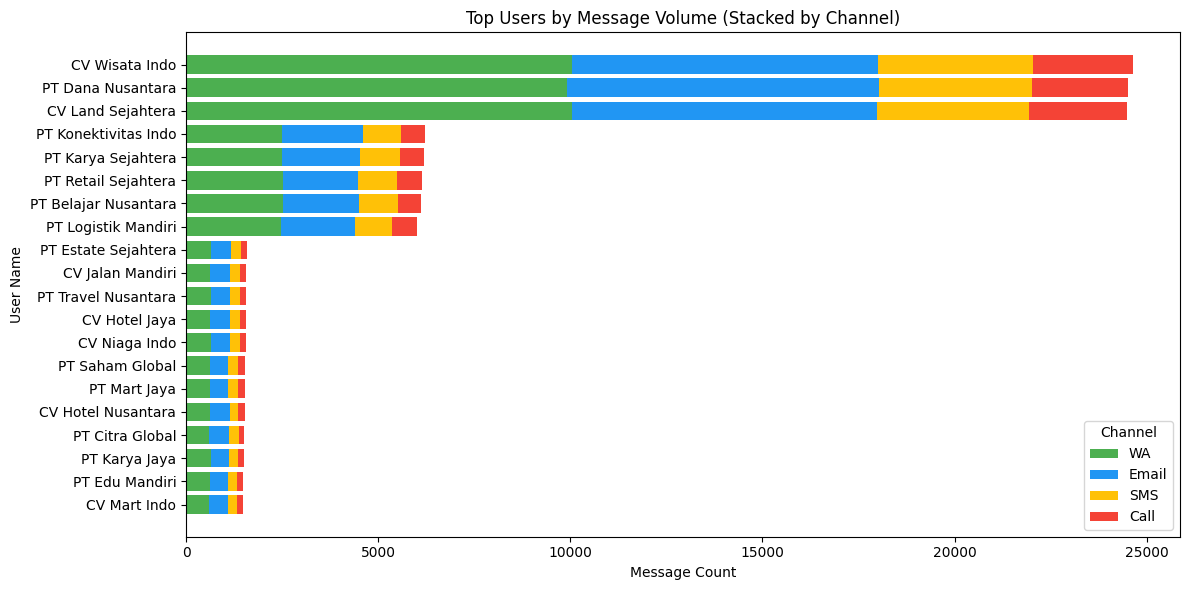

In [ ]:
def prep_tx (df, channel):
  tmp = df[['user_id', 'created_at']].copy()
  tmp['channel'] = channel
  tmp['date'] = tmp['created_at'].dt.date
  tmp['month'] = tmp['created_at'].dt.strftime('%Y-%m')
  return tmp

all_tx = pd.concat([
    prep_tx(df_whatsapp, 'WA'),
    prep_tx(df_email, 'Email'),
    prep_tx(df_sms, 'SMS'),
    prep_tx(df_call, 'Call')
])

# Visualisasi Top users by message volume berdasarkan channel (wa, email, sms, dan call) dengan stacked bar

# 1. Prepare combined transaction data with user names
# 'all_tx' is already created and contains 'user_id' and 'channel'
all_tx_with_names = all_tx.merge(df_users[['user_id', 'user_name']], on='user_id', how='left')

# 2. Calculate volume per user per channel
user_channel_volume = (
    all_tx_with_names
    .groupby(['user_name', 'channel'])
    .size()
    .unstack(fill_value=0) # This will create columns for each channel (e.g., 'Call', 'Email', 'SMS', 'WA')
)

# 3. Identify the top user names from the existing 'top_users' DataFrame
# 'top_users' is already calculated (e.g., in cell izb-PIGDWYrJ) and contains the top 5 users with 'user_name'
top_user_names_list = top_users['user_name'].tolist()

# 4. Filter the user_channel_volume for only these top users
# Ensure that the index of user_channel_volume is 'user_name' after unstacking
filtered_user_channel_volume = user_channel_volume.loc[user_channel_volume.index.isin(top_user_names_list)].copy()

# 5. Reorder the filtered DataFrame to match the order of top users by total volume (descending)
# First, calculate the total volume for filtering/sorting
filtered_user_channel_volume['total_volume'] = filtered_user_channel_volume.sum(axis=1)
filtered_user_channel_volume = filtered_user_channel_volume.sort_values(by='total_volume', ascending=True).drop(columns='total_volume')


channels_to_plot = ['WA', 'Email', 'SMS', 'Call'] # Explicitly define channels
colors_map = {
    'WA': '#4CAF50',
    'Email': '#2196F3',
    'SMS': '#FFC107',
    'Call': '#F44336'
}

plt.figure(figsize=(12, 6))

# Initialize left_stack for stacking the bars
left_stack = pd.Series([0.0] * len(filtered_user_channel_volume), index=filtered_user_channel_volume.index)

for ch in channels_to_plot:
    if ch in filtered_user_channel_volume.columns: # Check if the channel column exists in the data
        plt.barh(
            filtered_user_channel_volume.index, # User names as y-axis labels
            filtered_user_channel_volume[ch], # Volume for the current channel
            left=left_stack, # Where to start the bar for stacking
            label=ch, # Label for the legend
            color=colors_map.get(ch, 'grey') # Get color from map, default to grey
        )
        left_stack = left_stack + filtered_user_channel_volume[ch] # Update left_stack for the next channel

plt.title("Top Users by Message Volume (Stacked by Channel)")
plt.xlabel("Message Count")
plt.ylabel("User Name")
plt.legend(title="Channel")
plt.tight_layout()
plt.show()

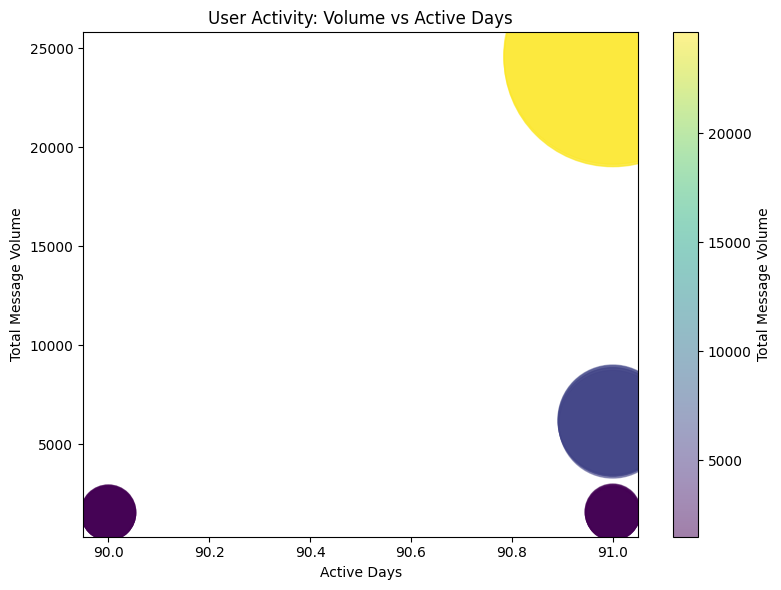

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    user_metrics['active_days'],
    user_metrics['total_volume'],
    s=user_metrics['total_volume'],   # bubble size
    c=user_metrics['total_volume'],   # Use 'c' for color based on a value
    cmap='viridis',
    alpha=0.5
)

plt.title("User Activity: Volume vs Active Days")
plt.xlabel("Active Days")
plt.ylabel("Total Message Volume")
plt.colorbar(label='Total Message Volume') # Add a colorbar to explain the color mapping
plt.tight_layout()
plt.show()

### **How many active users are there ?**

**Gabungkan semua channel**

In [ ]:
df_all = pd.concat(
    [df_whatsapp.assign(channel='whatsapp'),
     df_email.assign(channel='email'),
     df_sms.assign(channel='sms'),
     df_call.assign(channel='call')],
    ignore_index=True
)

df_all['date'] = pd.to_datetime(df_all['created_at']).dt.date
today = df_all['date'].max()

In [ ]:
# DAYS INACTIVE (overall)

last_activity = (
    df_all.groupby('user_id')['date']
    .max()
    .reset_index()
)

# Convert the timedelta Series to a proper pd.Timedelta Series
time_difference = pd.to_timedelta(today - last_activity['date'])
last_activity['days_inactive'] = time_difference.dt.days

In [ ]:
# USAGE DROP % (ALL CHANNEL)

last_30 = today - pd.Timedelta(days=30)
prev_30 = today - pd.Timedelta(days=60)

usage_last_30 = (
    df_all[df_all['date'] >= last_30]
    .groupby('user_id')
    .size()
)

usage_prev_30 = (
    df_all[
        (df_all['date'] >= prev_30) &
        (df_all['date'] < last_30)
    ]
    .groupby('user_id')
    .size()
)

usage_trend = pd.concat(
    [usage_last_30, usage_prev_30],
    axis=1,
    keys=['usage_last_30', 'usage_prev_30']
).fillna(0)

usage_trend['usage_drop_pct'] = (
    (usage_trend['usage_prev_30'] - usage_trend['usage_last_30'])
    / usage_trend['usage_prev_30']
).replace([float('inf'), -float('inf')], 0)

usage_trend = usage_trend.reset_index()


In [ ]:
# EVENUE DROP % (ALL CHANNEL)

rev_last_30 = (
    df_all[df_all['date'] >= last_30]
    .groupby('user_id')['price']
    .sum()
)

rev_prev_30 = (
    df_all[
        (df_all['date'] >= prev_30) &
        (df_all['date'] < last_30)
    ]
    .groupby('user_id')['price']
    .sum()
)

revenue_trend = pd.concat(
    [rev_last_30, rev_prev_30],
    axis=1,
    keys=['rev_last_30', 'rev_prev_30']
).fillna(0)

revenue_trend['revenue_drop_pct'] = (
    (revenue_trend['rev_prev_30'] - revenue_trend['rev_last_30'])
    / revenue_trend['rev_prev_30']
).replace([float('inf'), -float('inf')], 0)

revenue_trend = revenue_trend.reset_index()


In [ ]:
# ENGAGEMENT RATE PER CHANNEL

def success_rate(df, name):
    return (
        df.groupby('user_id')['quality_status']
        .apply(lambda x: (x == 'success').mean())
        .reset_index(name=f'{name}_success_rate')
    )

wa_rate   = success_rate(df_whatsapp, 'wa')
email_rate= success_rate(df_email, 'email')
sms_rate  = success_rate(df_sms, 'sms')
call_rate = success_rate(df_call, 'call')

In [ ]:
# GABUNG SEMUA KE churn_df
churn_df = (
    last_activity[['user_id', 'days_inactive']]
    .merge(usage_trend[['user_id', 'usage_drop_pct']], on='user_id', how='left')
    .merge(revenue_trend[['user_id', 'revenue_drop_pct']], on='user_id', how='left')
    .merge(wa_rate, on='user_id', how='left')
    .merge(email_rate, on='user_id', how='left')
    .merge(sms_rate, on='user_id', how='left')
    .merge(call_rate, on='user_id', how='left')
)


In [ ]:
churn_df = churn_df.fillna({
    'usage_drop_pct': 0,
    'revenue_drop_pct': 0,
    'wa_success_rate': 1,
    'email_success_rate': 1,
    'sms_success_rate': 1,
    'call_success_rate': 1
})


In [ ]:
# CHURN SCORE

churn_df['churn_score'] = (
    (churn_df['days_inactive'] >= 14).astype(int) * 2 +
    (churn_df['usage_drop_pct'] >= 0.3).astype(int) +
    (churn_df['revenue_drop_pct'] >= 0.3).astype(int) +
    (churn_df[['wa_success_rate',
               'email_success_rate',
               'sms_success_rate',
               'call_success_rate']] < 0.7).any(axis=1).astype(int)
)

churn_df

,user_id,days_inactive,usage_drop_pct,revenue_drop_pct,wa_success_rate,email_success_rate,sms_success_rate,call_success_rate,churn_score
0,user_1,0,0.135943,0.049782,0.846070,0.808894,0.994949,0.225693,1
1,user_10,0,0.112936,-0.009636,0.843393,0.804878,1.000000,0.192547,1
2,user_11,1,0.316434,0.168426,0.848200,0.796000,1.000000,0.243750,2
3,user_12,0,0.285985,0.233204,0.845238,0.817635,1.000000,0.228916,1
4,user_13,1,0.162000,0.10024,0.851200,0.822917,1.000000,0.226190,1
5,user_14,1,0.257299,0.195896,0.867742,0.827519,0.995575,0.198758,1
6,user_15,1,0.073222,-0.149887,0.825243,0.831197,1.000000,0.225166,1
7,user_16,0,0.051020,-0.048237,0.846273,0.826415,1.000000,0.173077,1
8,user_17,1,0.143145,0.051768,0.857585,0.803383,1.000000,0.217391,1
9,user_18,0,0.036585,-0.093477,0.834658,0.829077,0.996296,0.242424,1


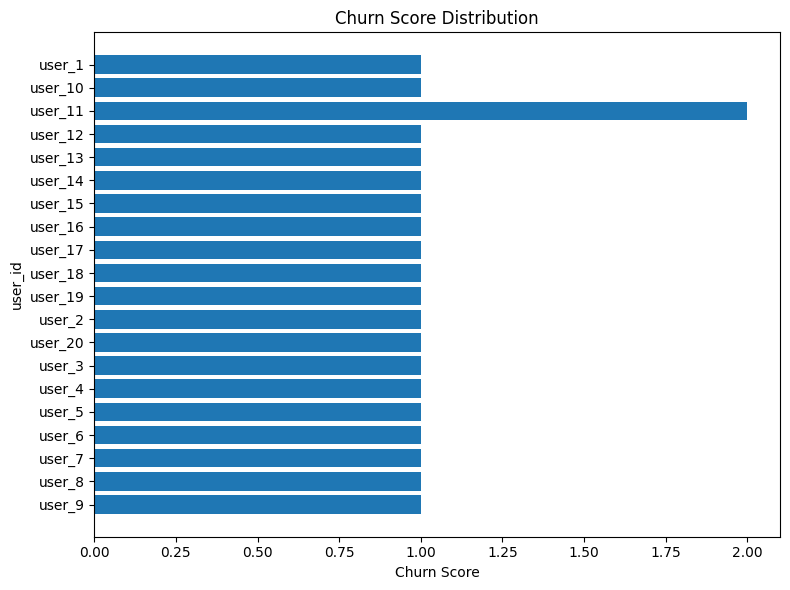

In [ ]:
# visualisasi churn score

plt.figure(figsize=(8,6))
plt.barh(churn_df['user_id'], churn_df['churn_score'])
plt.gca().invert_yaxis()

plt.title("Churn Score Distribution")
plt.xlabel("Churn Score")
plt.ylabel("user_id")
plt.tight_layout()
plt.show()



In [ ]:
# User redflag
redflag_users = churn_df[churn_df['churn_score'] >= 2]
redflag_users

,user_id,days_inactive,usage_drop_pct,revenue_drop_pct,wa_success_rate,email_success_rate,sms_success_rate,call_success_rate,churn_score
2,user_11,1,0.316434,0.168426,0.8482,0.796,1.0,0.24375,2


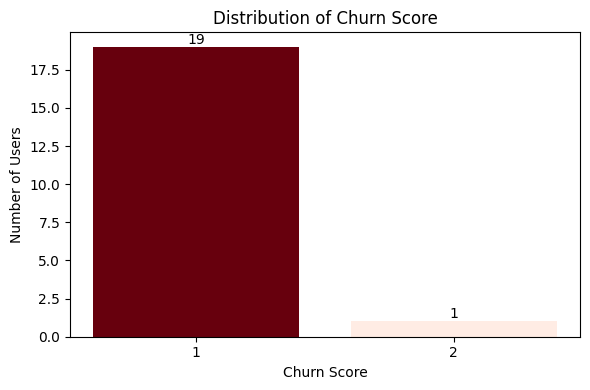

In [ ]:
counts = churn_df['churn_score'].value_counts().sort_index()

colors = plt.cm.Reds(counts.values / counts.values.max())

plt.figure(figsize=(6,4))
bars = plt.bar(counts.index.astype(str), counts.values, color=colors)

plt.title("Distribution of Churn Score")
plt.xlabel("Churn Score")
plt.ylabel("Number of Users")

# angka di atas bar
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{int(y)}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


## Product usage


### **How Many messages are sent per channel ?**

**PRODUCT USAGE (Health Check)**
Produk ini dipakai rame atau sepi?

In [ ]:
total_messages = df_all.shape[0]
active_users = df_all['user_id'].nunique()
active_days = df_all['date'].nunique()

summary = pd.DataFrame({
    'Metric': ['Total Messages', 'Active Users', 'Active Days'],
    'Value': [total_messages, active_users, active_days]
})

summary


,Metric,Value
0,Total Messages,122749
1,Active Users,20
2,Active Days,91


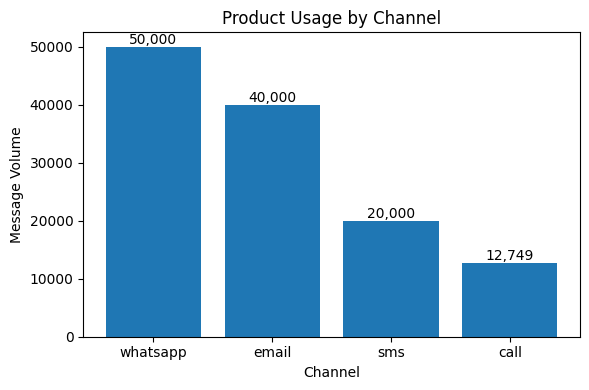

In [ ]:
# PRODUCT USAGE BY CHANNEL

channel_usage = (
    df_all
    .groupby('channel')
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
bars = plt.bar(channel_usage.index, channel_usage.values)

plt.title("Product Usage by Channel")
plt.xlabel("Channel")
plt.ylabel("Message Volume")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y, f'{int(y):,}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


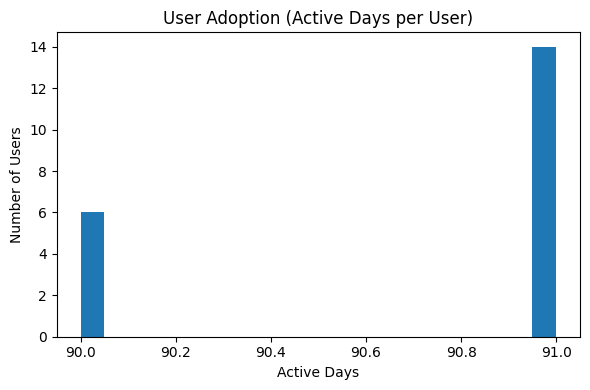

In [ ]:
# USER ADOPTION: Active Days per User
user_active_days = (
    df_all.groupby('user_id')['date']
    .nunique()
)

plt.figure(figsize=(6,4))
plt.hist(user_active_days, bins=20)

plt.title("User Adoption (Active Days per User)")
plt.xlabel("Active Days")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


In [ ]:
# PRODUCT Stickiness berbasis lifecycle
user_lifecycle = (
    df_all.groupby('user_id')['date']
    .agg(
        first_day='min',
        last_day='max',
        active_days='nunique'
    )
)

# Convert timedelta objects to pd.Timedelta Series before accessing .dt accessor
time_diff = user_lifecycle['last_day'] - user_lifecycle['first_day']
user_lifecycle['lifetime_days'] = pd.to_timedelta(time_diff).dt.days + 1

user_lifecycle['stickiness_ratio'] = (
    user_lifecycle['active_days'] / user_lifecycle['lifetime_days']
)

user_lifecycle['stickiness_ratio'].describe()

,stickiness_ratio
count,20.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
user_lifecycle

,first_day,last_day,active_days,lifetime_days,stickiness_ratio
user_id,,,,,
user_1,2025-01-01,2025-04-01,91,91,1.0
user_10,2025-01-01,2025-04-01,91,91,1.0
user_11,2025-01-01,2025-03-31,90,90,1.0
user_12,2025-01-01,2025-04-01,91,91,1.0
user_13,2025-01-01,2025-03-31,90,90,1.0
user_14,2025-01-01,2025-03-31,90,90,1.0
user_15,2025-01-01,2025-03-31,90,90,1.0
user_16,2025-01-01,2025-04-01,91,91,1.0
user_17,2025-01-01,2025-03-31,90,90,1.0


In [ ]:
# PRODUCT STICKINESS (DAU / MAU)

df_all['month'] = pd.to_datetime(df_all['date']).dt.to_period('M')

# DAU per hari
dau = (
    df_all.groupby('date')['user_id']
    .nunique()
)

# MAU per bulan
mau = (
    df_all.groupby('month')['user_id']
    .nunique()
)

# Rata-rata DAU per bulan

dau_df = dau.reset_index(name='dau')
dau_df['month'] = pd.to_datetime(dau_df['date']).dt.to_period('M')

avg_dau_per_month = (
    dau_df.groupby('month')['dau']
    .mean()
)


stickiness = (avg_dau_per_month / mau).dropna()
stickiness


,0
month,
2025-01,1.0
2025-02,1.0
2025-03,1.0
2025-04,1.0


In [ ]:
# CHANNEL DEPENDENCY ANALYSIS (Risk Bisnis)
user_channel_count = (
    df_all.groupby('user_id')['channel']
    .nunique()
)

user_channel_count.value_counts().sort_index()


,count
channel,
4,20


In [ ]:
# TOP USERS CONTRIBUTION (Revenue / Usage Risk)
user_usage = (
    df_all.groupby('user_id')
    .size()
    .sort_values(ascending=False)
)

top_10_share = user_usage.head(10).sum() / user_usage.sum()
top_10_share


np.float64(0.8757871754556045)

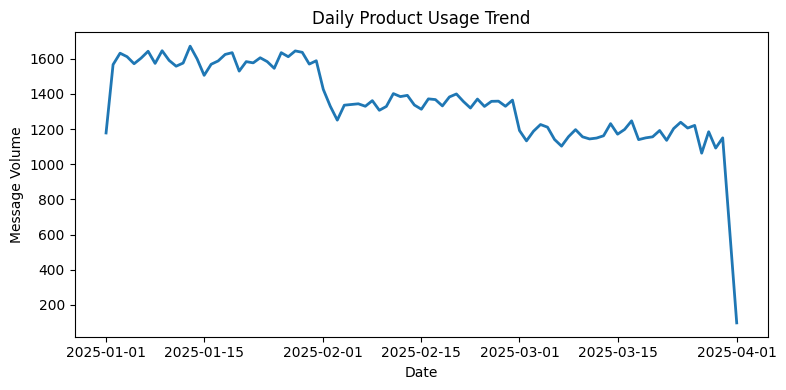

In [ ]:
# PRODUCT USAGE TREND (Growth / Decline)
daily_usage = (
    df_all.groupby('date')
    .size()
)

plt.figure(figsize=(8,4))
plt.plot(daily_usage, linewidth=2)

plt.title("Daily Product Usage Trend")
plt.xlabel("Date")
plt.ylabel("Message Volume")
plt.tight_layout()
plt.show()


In [ ]:
## Simpan dataset
df_users.to_csv('df_users.csv', index=False)
df_whatsapp.to_csv('df_whatsapp.csv', index=False)
df_email.to_csv('df_email.csv', index=False)
df_sms.to_csv('df_sms.csv', index=False)
df_call.to_csv('df_call.csv', index=False)

In [ ]:
# Menjadikan satu file seluruh dataset
df_all = pd.concat(
    [df_whatsapp.assign(channel='whatsapp'),
     df_email.assign(channel='email'),
     df_sms.assign(channel='sms'),
     df_call.assign(channel='call')],
    ignore_index=True
)

df_all.head(2)

,transaction_id,user_id,message_type,price,last_status,is_charge,created_at,received_timestamp,rt_missing_flag,received_missing,received_ts_filled,received_imputed,quality_status,channel,message_status,pk_collision,total_sms,total_price
0,6819609cde80fc0012abe3e1,user_1,marketing,400,delivered,True,2025-02-14 16:27:00+07:00,2025-02-14 16:29:00+07:00,False,False,2025-02-14 16:29:00+07:00,False,success,whatsapp,NaN,NaN,<NA>,<NA>
1,6838cb9a9eb51800120d7e4b,user_1,marketing,400,delivered,True,2025-01-02 23:21:00+07:00,2025-01-02 23:26:00+07:00,False,False,2025-01-02 23:26:00+07:00,False,success,whatsapp,NaN,NaN,<NA>,<NA>


## aaa

* Total Message Sent all channel is 122.749
* Tertinggi di WA (50k) dan terendah ada di call (12.749)
* Trend Email mengalamai penurunan dibandingkan ketiga channel lainnya yang terlihat stagnan



In [ ]:
# Total message all channel
total_messages_sent = (
    len(df_whatsapp) +
    len(df_email) +
    len(df_sms) +
    len(df_call)
)

total_messages_sent

In [ ]:
# Messages Sent Per Channel
messages_by_channel = (
    pd.concat(
        [
            df_whatsapp.assign(channel="whatsapp"),
            df_email.assign(channel="email"),
            df_sms.assign(channel="sms"),
            df_call.assign(channel="call")
        ], ignore_index=True
    )
    .groupby("channel")
    .size()
    .rename("messages_sent")
    .to_frame("messages_sent")
    .reset_index()
)

messages_by_channel


In [ ]:
# Messages Sent Trend
def prepare_trend(df, channel):
  return(
      df
      .assign(channel=channel,
              date=df["created_at"].dt.date)
      [["channel", "date"]]

  )

In [ ]:
message_trend = (
    pd.concat(
        [
            prepare_trend(df_whatsapp, "whatsapp"),
            prepare_trend(df_email, "email"),
            prepare_trend(df_sms, "sms"),
            prepare_trend(df_call, "call")
        ], ignore_index=True
    )
    .groupby(["channel", "date"])
    .size()
    .rename("messages_sent")
    .to_frame()
    .reset_index()
)


In [ ]:
# Message Trend - Monthly
message_trend['month'] = pd.to_datetime(message_trend['date']).dt.to_period('M').astype(str)

monthly_trend = (
    message_trend
    .groupby(['month', 'channel'])['messages_sent']
    .sum()
    .reset_index()
)

message_trend.head(5)

In [ ]:
assert message_trend['messages_sent'].ge(0).all()


In [ ]:
trend_pivot = (
    message_trend
    .pivot(index='date', columns='channel', values='messages_sent')
    .fillna(0)
)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
trend_pivot.plot(ax=plt.gca())
plt.title("Messages Sent Trend per Channel")
plt.xlabel("Date")
plt.ylabel("Messages Sent")
plt.tight_layout()
plt.show()


### **Active Users**

In [ ]:
# active_users per Day / 1 hari ada berapa user
df_whatsapp['date'] = df_whatsapp['created_at'].dt.date

daily_active_users = (
    df_whatsapp
    .groupby('date')['user_id']
    .nunique()
    .reset_index(name='DAU')
)
daily_active_users

In [ ]:
# active_users per Month (all Channel)

def prepare_active_users(df):
  return df[['user_id', 'created_at']]


all_tx = pd.concat([
    prepare_active_users(df_whatsapp),
    prepare_active_users(df_email),
    prepare_active_users(df_sms),
    prepare_active_users(df_call)
])

all_tx['month'] = all_tx['created_at'].dt.strftime('%Y-%m')

monthly_active_users = (
    all_tx
    .groupby('month')['user_id']
    .nunique()
    .reset_index(name='active_users')
)

monthly_active_users



In [ ]:
# Active Users per Channel & Month

def active_users_by_channel(df, channel_name):
    tmp = df[['user_id', 'created_at']].copy()
    tmp['month'] = tmp['created_at'].dt.strftime('%Y-%m')
    tmp['channel'] = channel_name
    return tmp

active_df = pd.concat([
    active_users_by_channel(df_whatsapp_rt, 'WA'),
    active_users_by_channel(df_email, 'Email'),
    active_users_by_channel(df_sms, 'SMS'),
    active_users_by_channel(df_call, 'Call')
])

active_users_channel_month = (
    active_df
    .groupby(['month', 'channel'])['user_id']
    .nunique()
    .reset_index(name='active_users') # Reset index first to get 'month' as a column
    .sort_values(by='month', ascending=False)
)
active_users_channel_month

In [ ]:
# Active Users per User (Untuk Churn / Power User)
active_days_per_user = (
    all_tx
    .assign(date=lambda x: x['created_at'].dt.date)
    .groupby('user_id')['date']
    .nunique()
    .reset_index(name='active_days')
)
active_days_per_user.describe()

### **transactions_per_user**

In [ ]:
# transactions_per_user


def prep_tx(df):
  return df[['user_id']]

all_tx = pd.concat([
    prep_tx(df_whatsapp),
    prep_tx(df_email),
    prep_tx(df_sms),
    prep_tx(df_call)
])

transactions_per_user = (
    all_tx
    .groupby('user_id')
    .size()
    .reset_index(name='transactions')
    .sort_values(by='transactions', ascending=False)
)


In [ ]:
# Paid Transactions per User

def prep_paid_tx(df, price_col):
  return (df.loc[df['is_charge'], ['user_id']])

paid_tx = pd.concat([
    prep_paid_tx(df_whatsapp, 'price'),
    prep_paid_tx(df_email, 'price'),
    prep_paid_tx(df_sms, 'total_price'),
    prep_paid_tx(df_call, 'total_price')
])

paid_transactions_per_user = (
    paid_tx
    .groupby('user_id')
    .size()
    .reset_index(name='paid_transactions')
    .sort_values(by='paid_transactions', ascending=False)
)

In [ ]:
# Transactions per User per Channel (Analisis Ketergantungan)

def tx_user_channel(df, channel):
  return (
      df.groupby('user_id')
      .size()
      .reset_index(name=f'transactions_{channel}')
      .assign(channel=channel)
  )

tx_user_channel_df = pd.concat([
      tx_user_channel(df_whatsapp, 'WA'),
      tx_user_channel(df_email, 'Email'),
      tx_user_channel(df_sms, 'SMS'),
      tx_user_channel(df_call, 'Call')
])

transactions_per_user.describe()

### **daily / monthly volume**

In [ ]:
def prepare_volume(df, channel_name):
  tmp = df[['created_at']].copy()
  # Ensure 'created_at' is datetime within this function's scope
  tmp['created_at'] = pd.to_datetime(tmp['created_at'], errors='coerce', utc=True)
  tmp['created_at'] = tmp['created_at'].dt.tz_convert('Asia/Jakarta')
  tmp['date'] = tmp['created_at'].dt.date
  tmp['month'] = tmp['created_at'].dt.strftime('%Y-%m')
  tmp['channel'] = channel_name # Use channel_name here
  return tmp

In [ ]:
# Daily Volume — All Channels

daily_volume = pd.concat([
    prepare_volume(df_whatsapp, 'WA'),
    prepare_volume(df_email, 'Email'),
    prepare_volume(df_sms, 'SMS'),
    prepare_volume(df_call, 'Call')
])

daily_volume_all = (
    daily_volume
    .groupby(['date', 'channel'])
    .size()
    .reset_index(name='volume')
)

In [ ]:
# Monthly Volume — All Channels

monthly_volume_all = (
    daily_volume
    .groupby(['month'])
    .size()
    .reset_index(name='volume')
)

In [ ]:
# Daily / Monthly Volume per Channel
daily_volume_channel = (
    daily_volume
    .groupby(['date', 'channel'])
    .size()
    .reset_index(name='daily_volume')
)

monthly_volume_channel = (
    daily_volume
    .groupby(['month', 'channel'])
    .size()
    .reset_index(name='monthly_volume')
)

In [ ]:
daily_volume_all.describe()
monthly_volume_all

### **Behavior Customer**

In [ ]:
def prep_tx (df, channel):
  tmp = df[['user_id', 'created_at']].copy()
  tmp['channel'] = channel
  tmp['date'] = tmp['created_at'].dt.date
  tmp['month'] = tmp['created_at'].dt.strftime('%Y-%m')
  return tmp

all_tx = pd.concat([
    prep_tx(df_whatsapp, 'WA'),
    prep_tx(df_email, 'Email'),
    prep_tx(df_sms, 'SMS'),
    prep_tx(df_call, 'Call')
])

In [ ]:
# Usage Intensity / sering bertransaksi / Top Users
tx_per_user = (
    all_tx
    .groupby('user_id')
    .size()
    .reset_index(name='transactions')
    .sort_values(by='transactions', ascending=False)
)
tx_per_user

In [ ]:
# Channel Preference / Channel sering dipakai

channel_pref = (
    all_tx
    .groupby(['user_id', 'channel'])
    .size()
    .reset_index(name='transactions')
    .sort_values(by='transactions', ascending=False)
)

dominant_channel = (
    channel_pref
    .sort_values(['user_id', 'transactions'], ascending=[True, False])
    .drop_duplicates('user_id')
    .rename(columns={'channel': 'dominant_channel'})
    .sort_values(by='dominant_channel', ascending=False)
)

dominant_channel

In [ ]:
df_whatsapp.head(2)

In [ ]:
# Consistency / aktif konsisten atau sporadis
active_days = (
    all_tx
    .groupby('user_id')['date']
    .nunique()
    .reset_index(name='active_days')
    .sort_values(by='active_days', ascending=False)
)

active_days


In [ ]:
# Monetary Value / Kontribusi Revenue

def revenue_prep(df, channel, price_col):
    tmp = df.loc[df['is_charge'], ['user_id', price_col]].copy()
    tmp['revenue'] = tmp[price_col]
    tmp['channel'] = channel
    return tmp[['user_id', 'revenue', 'channel']]

revenue_df = pd.concat([
    revenue_prep(df_whatsapp, 'WA', 'price'),
    revenue_prep(df_email, 'Email', 'price'),
    revenue_prep(df_sms, 'SMS', 'total_price'),
    revenue_prep(df_call, 'Call', 'total_price')
])

revenue_per_user = (
    revenue_df
    .groupby('user_id')['revenue']
    .sum()
    .reset_index(name='total_revenue')
    .sort_values(by='total_revenue', ascending=False)
)

revenue_per_user

In [ ]:
# Engagement Quality / delivered / read / answered

wa_quality = df_whatsapp.copy()

wa_quality['success'] = wa_quality['last_status'].isin(['delivered', 'read'])

engagement_rate = (
    wa_quality
    .groupby('user_id')['success']
    .mean()
    .reset_index(name='wa_success_rate')
    .sort_values(by='wa_success_rate', ascending=False)
)

engagement_rate

In [ ]:
# Trend Behavior (Naik / Turun)
monthly_usage = (
    all_tx
    .groupby(['user_id', 'month'])
    .size()
    .reset_index(name='monthly_volume')
)

usage_trend = (
    monthly_usage
    .groupby('user_id')['monthly_volume']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'avg_monthly_usage'})
    .sort_values(by='avg_monthly_usage', ascending=False)
)

usage_trend

In [ ]:
# Combine all Behavior

customer_behavior = (
    tx_per_user
    .merge(active_days, on='user_id', how='left')
    .merge(dominant_channel[['user_id', 'dominant_channel']], on='user_id', how='left')
    .merge(revenue_per_user, on='user_id', how='left')
    .merge(engagement_rate, on='user_id', how='left')
)

customer_behavior

In [ ]:
customer_behavior_detail = (
    customer_behavior
    .merge(df_users, on='user_id', how='left')
)

In [ ]:
customer_behavior['segment'] = pd.cut(
    customer_behavior['transactions'],
    bins=[0, 1000, 5000, 20000, float('inf')],
    labels=['Light', 'Medium', 'Heavy', 'Power']
)

In [ ]:
plt.scatter(
    customer_behavior['active_days'],
    customer_behavior['transactions'],
    alpha=0.6
)

plt.xlabel('Active Days')
plt.ylabel('Total Transactions')
plt.title('Customer Behavior: Intensity vs Consistency')
plt.show()

### **Sinyal Red Flag ( Behavioral Indicators)**

In [ ]:
from datetime import timedelta

all_tx = pd.concat([
    df_whatsapp[['user_id', 'created_at']],
    df_email[['user_id', 'created_at']],
    df_sms[['user_id', 'created_at']],
    df_call[['user_id', 'created_at']]
])

all_tx['date'] = all_tx['created_at'].dt.date


In [ ]:
# inactive / Dormant user

last_activity = (
    all_tx
    .groupby('user_id')['date']
    .max()
    .reset_index(name='last_activity')
)

lastest_date = all_tx['date'].max()

# Convert the timedelta Series to a proper pd.Timedelta Series
time_difference = pd.to_timedelta(lastest_date - last_activity['last_activity'])
last_activity['days_inactive'] = time_difference.dt.days

inactive_users = last_activity[
    last_activity['days_inactive'] >= 14
]

inactive_users

In [ ]:
# Usage Drop (Trend Menurun)

all_tx['month'] = all_tx['created_at'].dt.to_period('M')

monthly_usage = (
    all_tx
    .groupby(['user_id', 'month'])
    .size()
    .reset_index(name='volume')
)

latest_month = monthly_usage['month'].max()

usage_trend = (
    monthly_usage
    .groupby('user_id')
    .apply(lambda x: pd.Series({
        'lastest_volume': x.loc[x['month'] == latest_month, 'volume'].sum(),
        'avg_prev_volume': x.loc[x['month'] < latest_month, 'volume'].mean()
    }))
    .reset_index()
)

usage_trend['usage_drop'] = (
    1 - usage_trend['lastest_volume'] / usage_trend['avg_prev_volume']
)

usage_trend

In [ ]:
# Flag jika drop > 50%

usage_drop_users = usage_trend[
    usage_trend['usage_drop'] > 0.5
].sort_values(by='usage_drop', ascending=False)

usage_drop_users

In [ ]:
# Engagement Quality Drop
# (WA Example)
wa_quality = df_whatsapp.copy()
wa_quality['success'] = wa_quality['last_status'].isin(['delivered', 'read'])

quality_per_user = (
    wa_quality
    .groupby('user_id')['success']
    .mean()
    .reset_index(name='wa_success_rate')
)

low_quality_users = quality_per_user[
    quality_per_user['wa_success_rate'] < 0.7
].sort_values(by='wa_success_rate', ascending=False)

low_quality_users


In [ ]:
# Engagement Quality Drop
# (Email Example)
email_quality = df_email.copy()
email_quality['success'] = email_quality['message_status'].isin(['opened', 'delivered', 'clicked'])

quality_per_user = (
    email_quality
    .groupby('user_id')['success']
    .mean()
    .reset_index(name='email_success_rate')
)

low_quality_users = quality_per_user[
    quality_per_user['email_success_rate'] < 0.7
].sort_values(by='email_success_rate', ascending=False)

low_quality_users


In [ ]:
# Revenue Drop

revenue_tx = pd.concat ([
    df_whatsapp.loc[df_whatsapp['is_charge'], ['user_id', 'created_at', 'price']]
        .rename(columns={'price': 'revenue'}),
    df_email.loc[df_email['is_charge'], ['user_id', 'created_at', 'price']]
        .rename(columns={'price': 'revenue'}),
    df_sms.loc[df_sms['is_charge'], ['user_id', 'created_at', 'total_price']]
        .rename(columns={'total_price': 'revenue'}),
    df_call.loc[df_call['is_charge'], ['user_id', 'created_at', 'total_price']]
        .rename(columns={'total_price': 'revenue'})
])

revenue_tx['month'] = revenue_tx['created_at'].dt.to_period('M')

monthly_revenue = (
    revenue_tx
    .groupby(['user_id', 'month'])['revenue']
    .sum()
    .reset_index()
)

revenue_trend = (
    monthly_revenue
    .groupby('user_id')
    .apply(lambda x: pd.Series({
        'lastest_revenue': x.loc[x['month'] == latest_month, 'revenue'].sum(),
        'avg_prev_revenue': x.loc[x['month'] < latest_month, 'revenue'].mean()
    }))
    .reset_index()
)

revenue_trend['revenue_drop'] = (
    1 - revenue_trend['lastest_revenue'] / revenue_trend['avg_prev_revenue']
)

revenue_trend = revenue_trend.sort_values(by='revenue_drop', ascending=False)

revenue_trend

### Simpan Dataset baru "customer_churn_features"

In [ ]:
# Hitung Volume per period

recent_start = latest_date - timedelta(days=30)
previous_start = recent_start - timedelta(days=30)

recent_usage = (
    all_tx[all_tx['date'] >= recent_start]
    .groupby('user_id')
    .size()
    .reset_index(name='recent_volume')
)

previous_usage = (
    all_tx[
        (all_tx['date'] >= previous_start) &
        (all_tx['date'] < recent_start)
    ]
    .groupby('user_id')
    .size()
    .reset_index(name='previous_volume')
)


In [ ]:
# Gabungkan & hitung drop
usage_compare = recent_usage.merge(
    previous_usage,
    on='user_id',
    how='outer'
).fillna(0)

usage_compare['usage_drop_pct'] = (
    (usage_compare['recent_volume'] - usage_compare['previous_volume']) /
    usage_compare['previous_volume'].replace(0, np.nan)
).fillna(0)

In [ ]:
#  churn_features Vers.2

churn_features = churn_features.merge(
    usage_compare[['user_id', 'usage_drop_pct']],
    on="user_id",
    how="left"
).fillna({"usage_drop_pct": 0})

churn_features.head(2)

In [ ]:
df_whatsapp['last_status'].value_counts()

In [ ]:
# churn_features Vers.1

churn_features = (
    all_tx
    .groupby('user_id')
    .agg(
        total_volume=('created_at', 'count'),
        active_days=('date', 'nunique'),
        last_activity=('date', 'max'),
    )
    .reset_index()
)

latest_date = all_tx['date'].max()

# Convert the timedelta Series to a proper pd.Timedelta Series
time_difference = pd.to_timedelta(latest_date - churn_features['last_activity'])
churn_features['days_inactive'] = time_difference.dt.days

churn_features

In [ ]:
# WA SUCCESS RATE (QUALITY SIGNAL)

success_status = ["read", "delivered"]

# Success Rate WA

wa_stats = (
    df_whatsapp
    .groupby("user_id")
    .agg(
        wa_total=("created_at", "count"),
        wa_success=("last_status", lambda x: (x.isin(success_status)).sum())
    )
    .reset_index()
)

wa_stats["wa_success_rate"] = (wa_stats["wa_success"] / wa_stats["wa_total"])

In [ ]:
#  churn_features Vers.3

# Merge
churn_features = churn_features.merge(
    wa_stats[["user_id", "wa_success_rate"]],
    on="user_id",
    how="left"
).fillna({"wa_success_rate": 0})

churn_features.head(2)

In [ ]:
# Revenue Drop (%)

# paid_tx should be derived from revenue_tx, which already contains only charged transactions
paid_tx = revenue_tx.copy()

# Ensure 'date' column is available for filtering
paid_tx['date'] = paid_tx['created_at'].dt.date

# Revenue per period

recent_revenue = (
    paid_tx[paid_tx["date"] >= recent_start]
    .groupby("user_id")["revenue"]
    .sum()
    .rename("recent_revenue")
)

previous_revenue = (
    paid_tx[
        (paid_tx["date"] >= previous_start) &
        (paid_tx["date"] < recent_start)
    ]
    .groupby("user_id")["revenue"]
    .sum()
    .rename("previous_revenue")
)

previous_revenue.head(2)

In [ ]:
# Revenue drop %

revenue_compare = pd.concat(
    [recent_revenue, previous_revenue],
    axis=1
).fillna(0)

revenue_compare["revenue_drop_pct"] = (
    (revenue_compare["recent_revenue"] - revenue_compare["previous_revenue"]) /
    revenue_compare["previous_revenue"].replace(0, np.nan)
).fillna(0)

revenue_compare.head(2)

In [ ]:
#  churn_features Vers.4

# Merge

churn_features = churn_features.merge(
    revenue_compare[["revenue_drop_pct"]],
    on="user_id",
    how="left"
).fillna({"revenue_drop_pct": 0})

churn_features.head(2)

In [ ]:
churn_features["churn_score"] = (
    (churn_features["days_inactive"] >= 14).astype(int) +
    (churn_features["usage_drop_pct"] > 0.3).astype(int) +
    (churn_features["wa_success_rate"] < 0.7).astype(int) +
    (churn_features["revenue_drop_pct"] > 0.3).astype(int)
)

In [ ]:
churn_features = churn_features[[
    "user_id",
    "total_volume",
    "active_days",
    "days_inactive",
    "usage_drop_pct",
    "wa_success_rate",
    "revenue_drop_pct",
    "churn_score"
]]

churn_features

In [ ]:
churn_features.to_csv("customer_churn_features.csv", index=False)

### Simpan analisa menjadi satu

In [ ]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

df_call = clean_columns(df_call)
df_email = clean_columns(df_email)
df_sms = clean_columns(df_sms)
df_whatsapp = clean_columns(df_whatsapp)

df_call['channel'] = 'Call'
df_email['channel'] = 'Email'
df_sms['channel'] = 'SMS'
df_whatsapp['channel'] = 'Whatsapp'



/tmp/ipython-input-1078660350.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_call['channel'] = 'Call'
/tmp/ipython-input-1078660350.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_email['channel'] = 'Email'
/tmp/ipython-input-1078660350.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing

In [ ]:
cols = [
    'user_id',
    'created_at',
    'message_status',
    'channel'
]

# Ensure df_whatsapp has 'message_status' column
df_whatsapp['message_status'] = df_whatsapp['last_status']

df_call = df_call[cols]
df_email = df_email[cols]
df_sms = df_sms[cols]
df_whatsapp = df_whatsapp[cols]

### Summary Insight EDA
* **Total Message Sent** all channel is **122.749**
* **Tertinggi di WA (50k)** dan **terendah ada di call (12.749)**
* **Trend Email mengalamai penurunan** dibandingkan ketiga channel lainnya yang terlihat stagnan
* **Channel SMS** **lebih efektif** dan **Call yang tidak efektif** karena banyak ditemukan Failed
* **Tingginya Failed** di channel Call **disebabkan** oleh **RNA (Ring No Answer)**
* Traffic tertinggi pada **jam 18	sebesar 9.865**
* Traffic tertinggi pada **hari Friday 18.084**
* **Seluruh top users menunjukkan konsistensi maksimal** dengan aktif setiap hari (91)
* Berdasarkan **Volume** User_3 (**CV Wisata Indo**) merupakan pengguna tertinggi diikuti user_2 (**PT Dana Nusantara**) dan user_1 (**CV Land Sejahtera**)

1. **WhatsApp drives volume, SMS drives revenue, enabling a balanced omnichannel strategy.**
  * WhatsApp dominates transaction volume, while all active companies consistently use multiple channels, indicating strong demand for omnichannel communication.
  * Revenue Concentration Risk, >85% of revenue comes from SMS + WhatsApp.

2. **SMS for critical reliability, optimize WhatsApp and Email; limit Calls.**
* SMS is the most reliable channel, WhatsApp and Email show delivery delays, while Call is highly ineffective due to user non-response rather than technical failure.
* Overall Delivery Effectiveness Is Strong, but Delays Remain a Concern
* SMS is the most reliable channel. There are almost zero issues, making it suitable for critical communication.
* The main problem with Whatsatpp & Email is not that it fails, but that it has a high pending rate.
* Calls are not scalable and highly inefficient. The majority of calls are not connected, not due to technical issues, but rather user behavior (RNA).


3. **Engagement stable, volume concentrated, email declining, WhatsApp drives upsell opportunities.**
* While most clients are consistently active, message volume is highly concentrated among a few key users, indicating dependency risk and strong upselling potential among highly engaged but low-volume clients.
* User engagement peaks in the evening (18.00–23.00) and remains stable throughout the week, with the highest activity on Fridays, making evenings on weekdays the optimal window for blast messaging.
* The overall traffic decline is primarily driven by the decrease in Email usage, while the shift in user behavior toward WhatsApp highlights churn risk among Email-dependent clients and revenue opportunities through WhatsApp-focused engagement.
* Top users show strong engagement and low churn risk, but volume is highly concentrated among a few key accounts, highlighting dependency risk and significant upsell potential among consistently active yet low-volume clients.


**Recommendations**

1. **Kurangi Dependency Risk melalui Volume Diversification**
Volume dan revenue saat ini sangat terkonsentrasi pada sedikit klien dan channel (SMS & WhatsApp). OCA perlu mendorong peningkatan volume dari klien yang sudah aktif namun masih low-volume melalui paket bundling dan insentif usage.

2. **Shift Revenue Growth ke WhatsApp-Centric Strategy**
Perpindahan perilaku user dari Email ke WhatsApp menunjukkan peluang monetisasi yang kuat. Fokuskan WhatsApp sebagai channel utama untuk upsell, automation, dan value-added services.

3. **Protect SMS as Critical Revenue Backbone**
SMS terbukti paling reliable dan menjadi kontributor utama revenue. Strategi harus menjaga kualitas, pricing power, dan positioning SMS sebagai channel kritikal, bukan mass blast.

4. **Monetisasi Peak Engagement Window**
Dengan engagement tertinggi pada jam 18.00–23.00 dan hari kerja (khususnya Jumat), OCA dapat menawarkan time-based pricing, recommended send-time, atau campaign optimization services.

5. **Early Churn Mitigation for Email-Dependent Clients**
Penurunan usage Email menjadi sinyal awal churn. Klien dengan ketergantungan tinggi pada Email perlu diarahkan ke WhatsApp atau SMS melalui edukasi dan migration program.


## **Test Recommendation**

### **Reduce Dependency Risk through Volume Diversification**

In [ ]:

all_txt = pd.concat ([
  df_whatsapp.assign(channel='whatsapp', price=df_whatsapp["price"]),
  df_email.assign(channel='email', price=df_email["price"]),
  df_sms.assign(channel='sms', price=df_sms["price"]),
  df_call.assign(channel='call', price=df_call["total_price"])
], ignore_index=True)

In [ ]:
# Metrik Per User
all_txt['date'] = all_txt['created_at'].dt.date # Add date column to all_txt

user_metrics = (
  all_txt
  .groupby(["user_id"])
  .agg(
      total_tx=("transaction_id", "count"),
      total_volume=("price", "sum"),
      unique_channel=("channel", "nunique"),
      active_days=("date", "nunique") # Add active_days here
  )
  .reset_index()
)

user_metrics.head(2)

,user_id,total_tx,total_volume,unique_channel,active_days
0,user_1,24496,5152880,4,91
1,user_10,1525,318850,4,91


In [ ]:
# Identivikasi Low-Volume tapi Aktif

volume_threshold = user_metrics["total_tx"].quantile(0.3)
active_threshold = user_metrics["active_days"].quantile(0.7)

low_volume_active = user_metrics[
  (user_metrics["total_tx"] < volume_threshold) &
  (user_metrics["active_days"] > active_threshold)
]

low_volume_active

,user_id,total_tx,total_volume,unique_channel,active_days


In [ ]:
# Ukur Dependency Risk Saat ini

user_metrics["revenue_share"] = (
    user_metrics["total_volume"] /
    user_metrics["total_volume"].sum()
)

top_10_share = (
    user_metrics
    .sort_values("total_volume", ascending=False)
    .head(10)["revenue_share"]
    .sum()
)

top_10_share

np.float64(0.875475587664137)

In [ ]:
# VOLUME DIVERSIFICATION

volume_uplift = 0.30 # +30% volume
price_discount = 0.10 # -10% harga karena bundling

In [ ]:
# Revenue baru untuk low-volume active users

low_volume_active["simulated_tx"] = (
    low_volume_active["total_tx"] * (1 + volume_uplift)
)

low_volume_active["simulated_volume"] = (
    low_volume_active["simulated_tx"]
    * (1 + volume_uplift)
    * (1 - price_discount)
)

In [ ]:
# TOTAL REVENUE BARU

baseline_revenue = user_metrics["total_volume"].sum()

incremental_revenue = (
    low_volume_active["simulated_volume"].sum()
    - low_volume_active["total_volume"].sum()
)

new_total_revenue = baseline_revenue + incremental_revenue
print(f"Revenue Lama \n {revenue_df}")
print(f"Revenue Baru {new_total_revenue}")

Revenue Lama 
        total_revenue
WA          10257850
Email        1571350
SMS          9967000
Call         2304220
TOTAL       24100420
Revenue Baru 25768120.0


In [ ]:
selisih_revenue = new_total_revenue - revenue_df
selisih_revenue

,total_revenue
WA,15510270.0
Email,24196770.0
SMS,15801120.0
Call,23463900.0
TOTAL,1667700.0


In [ ]:
# Presentase selisih revenue

presentase_selisih = (selisih_revenue / revenue_df) * 100
presentase_selisih

,total_revenue
WA,151.203907
Email,1539.871448
SMS,158.534363
Call,1018.301204
TOTAL,6.919796


In [ ]:
user_metrics_sim = user_metrics.copy()

user_metrics_sim.loc[
    user_metrics_sim["user_id"].isin(low_volume_active["user_id"]),
    "total_tx"
] = low_volume_active.set_index("user_id")["simulated_volume"]

user_metrics_sim["revenue_share"] = (
    user_metrics_sim["total_volume"] /
    user_metrics_sim["total_volume"].sum()
)

top_10_share_after = (
    user_metrics_sim
    .sort_values("total_volume", ascending=False)
    .head(10)["revenue_share"]
    .sum()
)

top_10_share_after

np.float64(0.875475587664137)

In [ ]:
# RINGKASAN IMPACT

impact_summary = pd.DataFrame({
    "Metric": [
        "Baseline Revenue"
        , "Incremental Revenue"
        , "New Total Revenue"
        , "Top 10 Revenue Share (Before)"
        , "Top 10 Revenue Share (After)"
    ],
    "Value": [
        baseline_revenue
        , incremental_revenue
        , new_total_revenue
        , top_10_share
        , top_10_share_after
    ]
})

def format_value(row):
  if "Revenue" in row["Metric"]:
    return f"Rp {row['Value']:.0f}"
  elif "Share" in row ["Metric"]:
    return f"{row['Value']*100:.2f}%"
  else:
    return row["Value"]

impact_summary["Formatted Value"] = impact_summary.apply(format_value, axis=1)

impact_summary[["Metric", "Formatted Value"]]
impact_summary

,Metric,Value,Formatted Value
0,Baseline Revenue,2.576812e+07,Rp 25768120
1,Incremental Revenue,0.000000e+00,Rp 0
2,New Total Revenue,2.576812e+07,Rp 25768120
3,Top 10 Revenue Share (Before),8.754756e-01,Rp 1
4,Top 10 Revenue Share (After),8.754756e-01,Rp 1


In [ ]:
# VOLUME PER USER PER CHANNEL
user_channel_volume = (
  all_txt
  .groupby(['user_id', 'channel'])
  .size()
  .reset_index(name='volume')
)


In [ ]:
# TOTAL VOLUME PER USER
total_volume_user = (
    user_channel_volume
    .groupby("user_id")["volume"]
    .sum()
    .reset_index(name="total_volume")
)


In [ ]:
# DOMINANT CHANNEL
max_channel_volume = (
    user_channel_volume
    .groupby("user_id")["volume"]
    .max()
    .reset_index(name="max_channel_volume")
)

In [ ]:
# DEPENDENCY RISK SCORE
dependency_df = (
    total_volume_user
    .merge(max_channel_volume, on="user_id")
    .merge(channel_count, on="user_id", how="left") # Merge channel_count here
)

dependency_df["dependency_score"] = (
    (dependency_df["max_channel_volume"] / dependency_df["total_volume"])
)

In [ ]:
# JUMLAH CHANNEL ACTIVE PER USER

channel_count = (
    user_channel_volume
    .groupby("user_id")["channel"]
    .nunique()
    .reset_index(name="aktive_channel_count")
)


In [ ]:
# KLASIFIKASI RISIKO

def classify_risk(row):
  if row ["dependency_score"] >= 0.8 and row ["aktive_channel_count"] == 1:
    return "High Dependency Risk"
  elif row ["dependency_score"] >= 0.6:
    return "Medium Dependency Risk"
  else:
    return "Low Dependency Risk"

dependency_df["dependency_risk_level"] = dependency_df.apply(classify_risk, axis=1)

dependency_df.head(2)

,user_id,total_volume,max_channel_volume,aktive_channel_count,dependency_score,dependency_risk_level
0,user_1,24496,10037,4,0.409740,Low Dependency Risk
1,user_10,1525,613,4,0.401967,Low Dependency Risk


In [ ]:
# TOP USER PALING BERISIKO

dependency_df.sort_values (
    by = "dependency_score",
    ascending = False
)
dependency_df

,user_id,total_volume,max_channel_volume,aktive_channel_count,dependency_score,dependency_risk_level
0,user_1,24496,10037,4,0.409740,Low Dependency Risk
1,user_10,1525,613,4,0.401967,Low Dependency Risk
2,user_11,1559,639,4,0.409878,Low Dependency Risk
3,user_12,1487,588,4,0.395427,Low Dependency Risk
4,user_13,1530,625,4,0.408497,Low Dependency Risk
5,user_14,1523,620,4,0.407091,Low Dependency Risk
6,user_15,1488,618,4,0.415323,Low Dependency Risk
7,user_16,1593,644,4,0.404269,Low Dependency Risk
8,user_17,1510,646,4,0.427815,Low Dependency Risk
9,user_18,1573,629,4,0.399873,Low Dependency Risk


In [ ]:
# DISTRIBUSI RISIKO

dependency_df["dependency_risk_level"].value_counts(normalize=True)*100

,proportion
dependency_risk_level,
Low Dependency Risk,100.0


**Visualisasi UJI SEBELUM vs SESUDAH (CONCEPT DIVERSIFIKASI)**

In [ ]:
all_tx["date"] = pd.to_datetime(all_tx["date"])

cutoff_date = pd.to_datetime("2025-02-01")

all_tx["period"] = all_tx["date"].apply(
    lambda x: "before" if x < cutoff_date else "after"
)

In [ ]:
user_channel_period = (
    all_tx
    .groupby(["user_id", "channel", "period"])
    .size()
    .reset_index(name="volume")
)

# Merge with df_users to get 'user_name'
user_channel_period_with_name = user_channel_period.merge(
    df_users[['user_id', 'user_name']],
    on='user_id',
    how='left'
)

summary = (
    user_channel_period_with_name
    .groupby(["user_name", "period"])
    .agg(
        total_volume=("volume", "sum"),
        unique_channels=("channel", "nunique"), # Added missing comma here
        max_channel_volume=("volume", "max") # Calculate max_channel_volume here if needed for dependency ratio
    )
    .reset_index()
)

# Calculate dependency_ratio correctly using existing columns
summary["dependency_ratio"] = (
 summary["max_channel_volume"] / summary["total_volume"]
)

In [ ]:
comparison = (
    summary
    .pivot(index="user_name", columns="period", values="dependency_ratio")
    .dropna()
    .reset_index()
)

comparison["dependency_change"]=(
    comparison["after"] - comparison["before"]
)

comparison

period,user_name,after,before,dependency_change
0,CV Hotel Jaya,0.458999,0.396748,0.062251
1,CV Hotel Nusantara,0.440000,0.406355,0.033645
2,CV Jalan Mandiri,0.443266,0.412698,0.030568
3,CV Land Sejahtera,0.442845,0.402350,0.040495
4,CV Mart Indo,0.438063,0.414023,0.024040
5,CV Niaga Indo,0.443038,0.390728,0.052309
6,CV Wisata Indo,0.442406,0.404305,0.038100
7,PT Belajar Nusantara,0.452938,0.403523,0.049415
8,PT Citra Global,0.433619,0.430769,0.002850
9,PT Dana Nusantara,0.439827,0.405247,0.034580


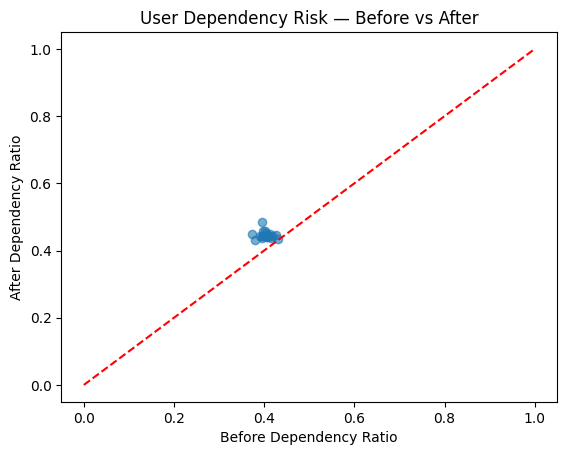

In [ ]:
plt.scatter(
    comparison["before"],
    comparison["after"],
    alpha=0.6
)

plt.plot([0,1], [0,1], linestyle="--", color="red")
plt.xlabel("Before Dependency Ratio")
plt.ylabel("After Dependency Ratio")
plt.title("User Dependency Risk — Before vs After")
plt.show()

### **Shift Revenue Growth to WhatsApp-Centric Strategy**


Focus on WhatsApp as the primary channel for upsells, automation, and value-added services.

In [ ]:
df_whatsapp["revenue"] = df_whatsapp.loc[df_whatsapp["is_charge"], "price"]
df_email["revenue"] = df_email.loc[df_email["is_charge"], "price"]
df_sms["revenue"] = df_sms.loc[df_sms["is_charge"], "price"]
df_call["revenue"] = df_call.loc[df_call["is_charge"], "total_price"]

**Saat Ini**

In [ ]:
# Revenue per Channel
baseline_revenue = {
    "Whatsapp": df_whatsapp["revenue"].sum(),
    "Email": df_email["revenue"].sum(),
    "SMS": df_sms["revenue"].sum(),
    "Call": df_call["revenue"].sum()
}

baseline_df = (
    pd.DataFrame.from_dict(baseline_revenue, orient="index", columns=["Revenue"])
    .reset_index()
    .rename(columns={"index": "Channel"})
)

baseline_df["revenue_share"] = (
    baseline_df["Revenue"] / baseline_df["Revenue"].sum()
)

baseline_df

,Channel,Revenue,revenue_share
0,Whatsapp,10257850,0.425630
1,Email,1571350,0.065200
2,SMS,9967000,0.413561
3,Call,2304220,0.095609


**WhatsApp-Centric Strategy**

In [ ]:
# Asumsikan

wa_volume_uplift = 0.35 # +35% volume WA (upsell + automations)
wa_price_uplift = 0.15  # +15% ARPU (value-added services)
other_channel_decay = 0.05 # -5% revenue non-WA (shift focus)

In [ ]:
# Simulasi setelah Wa Strategy

after_revenue = {
    "Whatsapp": baseline_revenue["Whatsapp"]
    * (1 + wa_volume_uplift)
    * (1 + wa_price_uplift),

    "Email" : baseline_revenue["Email"]*(1 - other_channel_decay),
    "SMS" : baseline_revenue["SMS"]*(1 - other_channel_decay),
    "Call" : baseline_revenue["Call"]*(1 - other_channel_decay)
}
after_revenue

{'Whatsapp': np.float64(15925312.124999998),
 'Email': np.float64(1492782.5),
 'SMS': np.float64(9468650.0),
 'Call': np.float64(2189009.0)}

In [ ]:
# Compare Before vs After

comparison_df = pd.DataFrame({
    "Channel" : baseline_df["Channel"],
    "Revenue_Before" : baseline_df["Revenue"],
    "Revenue_After" : [
        after_revenue["Whatsapp"],
        after_revenue["Email"],
        after_revenue["SMS"],
        after_revenue["Call"],
    ]
})

comparison_df["Delta_Revenue"] = (
    comparison_df["Revenue_After"] - comparison_df["Revenue_Before"]
)

comparison_df["Revenue_Share_After"] = (
    comparison_df["Revenue_After"] / comparison_df["Revenue_After"].sum()
)

comparison_df

,Channel,Revenue_Before,Revenue_After,Delta_Revenue,Revenue_Share_After
0,Whatsapp,10257850,1.592531e+07,5667462.125,0.547718
1,Email,1571350,1.492782e+06,-78567.500,0.051341
2,SMS,9967000,9.468650e+06,-498350.000,0.325654
3,Call,2304220,2.189009e+06,-115211.000,0.075286


In [ ]:
# Tambah Total & Mix Impact

comparison_df.loc["TOTAL"] = [
    "TOTAL",
    comparison_df["Revenue_Before"].sum(),
    comparison_df["Revenue_After"].sum(),
    comparison_df["Delta_Revenue"].sum(),
    comparison_df["Revenue_After"].sum() / comparison_df["Revenue_Before"].sum()
]

comparison_df

,Channel,Revenue_Before,Revenue_After,Delta_Revenue,Revenue_Share_After
0,Whatsapp,10257850,1.592531e+07,5667462.125,0.547718
1,Email,1571350,1.492782e+06,-78567.500,0.051341
2,SMS,9967000,9.468650e+06,-498350.000,0.325654
3,Call,2304220,2.189009e+06,-115211.000,0.075286
TOTAL,TOTAL,24100420,2.907575e+07,4975333.625,1.206442


In [ ]:
# Combine

def fmt_currency(x):
    return f"Rp {x:,.0f}"

def fmt_pct(x):
    return f"{x:.1f}%"

# Convert formatted string columns back to numeric for calculation
numeric_revenue_before = comparison_df["Revenue_Before"].astype(str).str.replace('Rp ', '', regex=False).str.replace(',', '', regex=False).astype(float)
numeric_revenue_after = comparison_df["Revenue_After"].astype(str).str.replace('Rp ', '', regex=False).str.replace(',', '', regex=False).astype(float)
numeric_delta_revenue = comparison_df["Delta_Revenue"].astype(str).str.replace('Rp ', '', regex=False).str.replace(',', '', regex=False).astype(float)


# Calculate Growth_%
growth_percentage = ((numeric_revenue_after - numeric_revenue_before) / numeric_revenue_before.replace(0, np.nan)) * 100
comparison_df["Growth_%"] = growth_percentage.fillna(0) # Fill NaN/inf from division by zero with 0


# Now re-apply formatting to ensure all columns are consistently formatted after calculations
comparison_df["Revenue_Before"] = numeric_revenue_before.apply(fmt_currency)
comparison_df["Revenue_After"] = numeric_revenue_after.apply(fmt_currency)
comparison_df["Delta_Revenue"] = numeric_delta_revenue.apply(fmt_currency)
comparison_df["Growth_%"] = comparison_df["Growth_%"] .apply(fmt_pct)

comparison_df

,Channel,Revenue_Before,Revenue_After,Delta_Revenue,Revenue_Share_After,Growth_%
0,Whatsapp,"Rp 10,257,850","Rp 15,925,312","Rp 5,667,462",0.547718,55.2%
1,Email,"Rp 1,571,350","Rp 1,492,782","Rp -78,568",0.051341,-5.0%
2,SMS,"Rp 9,967,000","Rp 9,468,650","Rp -498,350",0.325654,-5.0%
3,Call,"Rp 2,304,220","Rp 2,189,009","Rp -115,211",0.075286,-5.0%
TOTAL,TOTAL,"Rp 24,100,420","Rp 29,075,754","Rp 4,975,334",1.206442,20.6%


### **Protect SMS as Critical Revenue Backbone**

Maintain the quality, pricing power, and positioning of SMS as a critical channel, not a mass blast.

Revenue stability, Margin / pricing power, Quality, Revenue concentration risk, dan resilience when other channel are problems

In [ ]:
df_sms["revenue"] = df_sms.loc[df_sms["is_charge"], "total_price"]

In [ ]:
# Baseline - Situasi SMS saat ini
sms_baseline = (
    df_sms
    .groupby("user_id")
    .agg(
        sms_tx=("transaction_id", "count"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

sms_baseline.head(2)


,user_id,sms_tx,revenue
0,user_1,3960,2282000
1,user_10,259,156000


In [ ]:
# Total SMS KPI

sms_total_tx = sms_baseline["sms_tx"].sum()
sms_total_revenue = sms_baseline["revenue"].sum()
sms_avg_price = sms_total_revenue / sms_total_tx

In [ ]:
# SMS Quality

sms_success_rate = (
    df_sms["message_status"]
    .value_counts(normalize=True)
    .get("sent", 0)
)

sms_success_rate

np.float64(0.9967)

**IDENTIFIKASI SMS SEBAGAI BACKBONE (MISSION-CRITICAL USERS)**

In [ ]:
sms_backbone_users = sms_baseline[
    sms_baseline["revenue"] >= sms_baseline["revenue"].quantile(0.7)
]

In [ ]:
# Strategi Protect SMS
price_increase = 0.08        # +8% pricing power
volume_change = -0.05       # -5% volume (no mass blast)
quality_improvement = 0.02  # +2% delivery success


In [ ]:
# simulasinya setelah strategi (SMS Only)

sms_after_revenue = (
    sms_total_revenue
    * (1 + price_increase)
    * (1 + volume_change)
)

sms_after_total_tx = sms_total_tx * (1 + volume_change)
sms_after_avg_price = sms_after_revenue / sms_after_total_tx

sms_after_success_rate = (
    sms_success_rate
    * (1 + price_increase)
)

sms_after_success_rate = sms_success_rate + quality_improvement
sms_after_success_rate

np.float64(1.0167)

In [ ]:
# Bandingkan revenue stability (Volatility) / bulan

sms_monthly = (
    df_sms
    .assign(month=df_sms["created_at"].dt.to_period("M"))
    .groupby("month")["revenue"]
    .sum()
)

baseline_volatility = sms_monthly.std() / sms_monthly.mean()

after_volaitility = baseline_volatility * 0.85  # asumsi stabilitas naik

/tmp/ipython-input-2944221031.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=df_sms["created_at"].dt.to_period("M"))


In [ ]:
# PROTEKSI TERHADAP DEPENDENCY RISK
# Revenue share Top SMS users

sms_baseline["revenue_share"] = (
    sms_baseline["revenue"] / sms_baseline["revenue"].sum()
)

top_5_sms_share_before = (
    sms_baseline
    .sort_values("revenue_share", ascending=False)
    .head(5)["revenue_share"]
    .sum()
)

top_5_sms_share_before

top_5_sms_share_after = top_5_sms_share_before * 0.98


In [ ]:
# Ringkasan Impact
impact_df = pd.DataFrame({
    "Metric": [
        "Total SMS Revenue",
        "Avg Price per SMS",
        "SMS Success Rate",
        "Revenue Volatility (CV)",
        "Top 5 SMS Revenue Share"
    ],
    "Before": [
        sms_total_revenue,
        sms_avg_price,
        sms_success_rate,
        baseline_volatility,
        top_5_sms_share_before
    ],
    "After": [
        sms_after_revenue,
        sms_after_avg_price,
        sms_after_success_rate,
        after_volaitility,
        top_5_sms_share_after
    ]
})

impact_df["Impact"] = impact_df["After"] - impact_df["Before"]
impact_df["Impact %"] = (impact_df["Impact"] / impact_df["Before"]) * 100
impact_df

,Metric,Before,After,Impact,Impact %
0,Total SMS Revenue,1.181300e+07,1.212014e+07,307138.000000,2.600000
1,Avg Price per SMS,5.906500e+02,6.379020e+02,47.252000,8.000000
2,SMS Success Rate,9.967000e-01,1.016700e+00,0.020000,2.006622
3,Revenue Volatility (CV),5.530130e-02,4.700610e-02,-0.008295,-15.000000
4,Top 5 SMS Revenue Share,6.999492e-01,6.859502e-01,-0.013999,-2.000000


# **Visualisasi dengan Looker Studio**

In [ ]:
!pip install gspread gspread_dataframe


In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
import gspread
from gspread_dataframe import set_with_dataframe
from google.colab import auth
import google.auth

# Ensure user is authenticated (already run in a previous cell, but good practice to keep for context)
auth.authenticate_user()

# Get default credentials from the authenticated session
creds, project = google.auth.default()

gc = gspread.authorize(creds)

sh = gc.create('OCA_Dashboard_Data')
worksheet = sh.add_worksheet(title='channel_performance', rows=1000, cols=20)

set_with_dataframe(worksheet, effectiveness_df)

# Visualisasi Streamlit

In [ ]:
pip install streamlit pandas

In [ ]:
!pip install -q streamlit
!npm install localtunnel

In [ ]:
%%writefile app.py
import streamlit as st

st.title("My Streamlit App in Colab")
st.write("Hello, *world!* :sunglasses:")

# Add an interactive widget
user_input = st.text_input("Mikhael", "User")
st.write(f"Hello, {user_input}!")


In [ ]:
! curl http://loca.lt/mytunnelpassword

In [ ]:
# Run the streamlit app in the background
!streamlit run app.py &>/content/logs.txt &

# Expose the app on port 8501
!npx localtunnel --port 8501


## Visualisasi Streamlit Project OCA Indonesia

In [ ]:
! VI-OCA.py

In [ ]:
%%writefile VI-OCA.py
import streamlit as st
import pandas as pd

st.set_page_config(layout='wide')

st.title('Performance Report Analysis - OCA Indonesia')

st.write("Selamat datang di dashboard analitik performa layanan OCA Indonesia.")

st.header("Gambaran Umum")
st.write("""
    Dashboard ini menyajikan metrik-metrik kunci dari berbagai kanal komunikasi (WhatsApp, Email, SMS, Call) untuk memberikan insight tentang efektivitas kanal, perilaku pelanggan, dan indikator churn.
    Data yang digunakan adalah transaksi komunikasi dan informasi pengguna dari BigQuery.
""")

# Anda bisa menambahkan lebih banyak komponen Streamlit di sini
# Misalnya, untuk menampilkan dataframe jika sudah dimuat:
# if 'df_whatsapp' in locals():
#     st.subheader("Data WhatsApp")
#     st.dataframe(df_whatsapp.head())

# Menambahkan placeholder untuk visualisasi
st.subheader("Metrik Umum")
st.markdown("*(Visualisasi total transaksi, pendapatan, dll. akan muncul di sini)*")

st.subheader("Efektivitas Kanal")
st.markdown("*(Grafik efektivitas kanal: success, pending, failed akan muncul di sini)*")

st.subheader("Perilaku Pelanggan")
st.markdown("*(Analisis traffic berdasarkan jam/hari, top users, tren penggunaan, dll. akan muncul di sini)*")

st.subheader("Sinyal Churn")
st.markdown("*(Analisis churn score, inactive users, usage drop, dll. akan muncul di sini)*")


In [ ]:
import streamlit as st
import pandas as pd

title = "Performance Report Analysis - OCA Indonesia"
st.title(title)

In [ ]:
!streamlit run VI-OCA.py